In [1]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_alligned_response" # change this to the subfolder it should save to

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "8"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

if date == "20210404":
    marks_group_name = "mpfc1"
else:
    marks_group_name = "mpfc"
marks_group_name = "mpfc_HYBRID"

model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=6)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-09 14:11:55,557][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-09-09 14:12:15.395589: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-09 14:12:17.134055: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-09 14:12:19.223520: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-09-09 14:12:37,050][WARNING]: Skipped checksum for file

In [3]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]
analysis.fit_context_pca(fit_intervals = run_epochs)

t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

# Load Data

### Trial and decoding dataframes

In [4]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[14:17:03][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[14:17:03][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

### Sorted Spikes

In [5]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

[14:18:07][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

In [6]:
if "hybrid" in marks_group_name.lower():
    W = analysis.params["params"]["embedding"]["encoder"]["sorted_encoder"]["encoder_matrix"]
    z_neuron = W @ analysis.pca.components_.T
    z_mean = z_neuron.copy()

else:
    from c3po.tables.sorted_waveforms import EmbeddedSortedWaveform
    from c3po.analysis.intervals import interval_list_contains_ind

    sorted_df = (EmbeddedSortedWaveform & model_key).fetch_dataframe()
    z_neuron = []
    from tqdm import tqdm
    for z, z_times in tqdm(zip(sorted_df.z.values, sorted_df.spike_times.values)):
        ind = interval_list_contains_ind(run_epochs, z_times)
        z_mean = np.mean(z[ind], axis=0)
        z_neuron.append(z_mean @ analysis.pca.components_.T)
    sorted_df["z_neuron"] = z_neuron

# Aligned mean responses

### All trials, task-progression demo

In [7]:
mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

group = trial_df
group = group[group.n_pre_switch>0]

In [8]:
compiled_results = {m:[] for m in mark_list}
compiled_results_per_trial = {m:[] for m in mark_list}
compiled_values_per_trial = {m:[] for m in mark_list}
from scipy.ndimage import gaussian_filter1d


bin_size = 0.002
sig_smooth = 0.015

# bin_size = .1
from tqdm import tqdm
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    # for group, label, color in zip(condition_groups, condition_labels, condition_colors):
    t_bins_seg = np.arange(*range_val, bin_size)
    results = np.zeros((len(spikes), len(t_bins_seg) - 1))
    results_per_trial = np.zeros((len(spikes), len(t_bins_seg) - 1, len(group)))
    trial_marks = group[mark]
    for i_mark, m in enumerate(tqdm(trial_marks)):
        # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins_reward + m, smoothing_sigma=.01)
        # results.append(rates)
        for i, s in enumerate(spikes):
            st = np.searchsorted(s, m + t_bins_seg[0])
            en = np.searchsorted(s, m + t_bins_seg[-1])
            if en <= st:
                continue
            delays = s[st:en] - m
            v = np.histogram(delays, bins=t_bins_seg)[0]

            v = v / (len(trial_marks) * bin_size)
            # v = smooth_signal(v, sig_smooth, bin_size)
            # v = gaussian_filter1d(v, sig_smooth/bin_size)
            results[i, :] += v
            results_per_trial[i, :, i_mark] = v
    results = np.array(results)
    results = gaussian_filter1d(results, sig_smooth/bin_size, axis=1)
    compiled_results[mark].append(results)
    # compiled_results_per_trial[mark].append(results_per_trial)
    # compiled_values_per_trial[mark].append(group[condition_feature].values)

 97%|█████████▋| 1087/1122 [00:19<00:00, 64.03it/s]

100%|██████████| 1122/1122 [00:14<00:00, 75.80it/s]


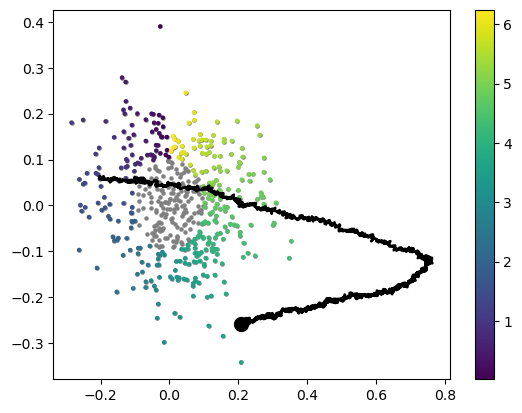

In [14]:
pc_inds = (3,1)
pc_inds = np.array([1,3])

thresh = .1
# pc_inds = np.array([6,5])

# z_neuron = [zz for zz in sorted_df.z_neuron.values]

z_neuron = analysis.params['params']['embedding']['encoder']['sorted_encoder']['encoder_matrix']
z_neuron = z_neuron @ analysis.pca.components_.T


z_neuron = np.array(z_neuron)[:, pc_inds]
z_mag = np.linalg.norm(z_neuron, axis=1)
z_angle = np.arctan2(z_neuron[:, 1], z_neuron[:, 0])

# rot = np.pi / 4
# rot= - np.pi * (3/2)
# rot += np.pi * (3/8)
rot = np.pi/2
z_angle = (z_angle + np.pi+rot)%(2*np.pi)


target_c = mid[:,pc_inds].copy()
target_angles = np.arctan2(target_c[:,1], target_c[:,0])


ind_sig = np.where(z_mag > thresh)[0]
ind_sorted = ind_sig[np.argsort(z_angle[ind_sig])]

plt.scatter(z_neuron[:, 0], z_neuron[:, 1], color="grey", s=5, alpha = 1)
plt.scatter(z_neuron[ind_sig, 0], z_neuron[ind_sig, 1], c=z_angle[ind_sig], cmap="viridis", s=5)

plt.colorbar()
plt.plot(target_c[:, 0]/3, target_c[:, 1]/3, color="black", linewidth=2)
plt.scatter(target_c[0, 0]/3, target_c[0, 1]/3, color="black", s=100)

In [51]:
xx[0].shape

(329, 39)

(1, 497, 999)
(1, 497, 499)
(1, 497, 749)
(329,) (329,)
(329,) (329,)


Text(0, 0.5, 'neuron_id')

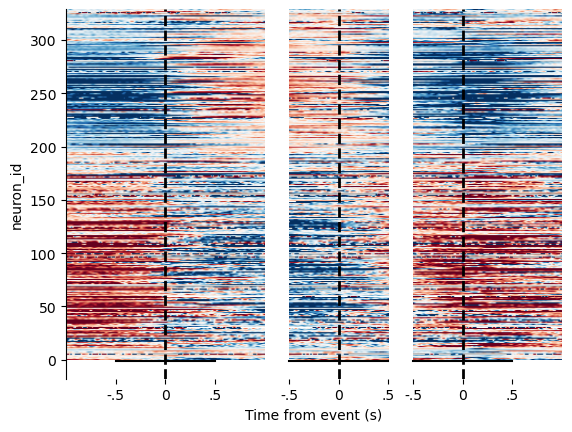

In [17]:
np.array(compiled_results['run_start'])[0].shape, ind_sorted.shape

xx = []
for v in compiled_results.values():
    print(np.array(v).shape)
    xx.append(np.array(v)[0][ind_sorted, :])

seg_lens = [x.shape[1] for x in xx]
seg_lens = seg_lens / np.sum(seg_lens)
rate_means = np.array([np.mean(x, axis=1) for x in xx])
rate_means = (rate_means * seg_lens[:, np.newaxis]).sum(axis=0)
print(rate_means.shape, z_angle[ind_sorted].shape)

# normalize by running rate only
seg_lens = []
seg_means = []
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    v = np.array(compiled_results[mark])[0]
    t_rng = np.linspace(range_val[0], range_val[1], v.shape[1])
    if mark == "run_start":
        ind_valid = np.where(t_rng > 0)[0]
    elif mark == "t_choice":
        ind_valid = np.arange(v.shape[1])
    elif mark == "t_poke":
        ind_valid = np.where(t_rng < 0)[0]
    seg_lens.append(len(ind_valid))
    seg_means.append(np.mean(v[:, ind_valid], axis=1))
seg_lens = np.array(seg_lens)
seg_lens = seg_lens / np.sum(seg_lens)
rate_means = np.array(seg_means)
rate_means = (rate_means * seg_lens[:, np.newaxis]).sum(axis=0)[ind_sorted]


print(rate_means.shape, z_angle[ind_sorted].shape)

# v = compiled_results['run_start']
# v = compiled_results['t_choice']
# v = compiled_results['t_poke']
# v = np.array(v)[0][ind_sorted, :]/rate_means[:,None]
# plt.imshow(np.log2(v), cmap ="RdBu", clim = (-2,2), aspect='auto')
# plt.colorbar()

fig = plt.figure()
ax = fig.gca()
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    v = compiled_results[mark]
    v = np.array(v)[0][ind_sorted, :]/rate_means[:,None]
    ax.imshow(np.log2(v), cmap ="RdBu_r", clim = (-1,1),aspect='auto',
               extent=[range_val[0]+offset, range_val[1]+offset, 0, len(ind_sorted)],
               rasterized=True)

ax.set_xlim(range_list[0][0]+offset_list[0], range_list[-1][1]+offset_list[-1])


ticks = []
labels = []
for mark, offset in zip(mark_list, offset_list):
    xx = np.array([-0.5, 0, 0.5])
    ticks.append(xx + offset)
    labels.append(["-.5", "0", ".5"])
    ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ax.axvline(offset, color="k", linestyle="--", lw=2)
ticks = np.concatenate(ticks)
labels = np.concatenate(labels)
ax.set_xticks(ticks, labels)
ax.set_xlabel("Time from event (s)")

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = 'x', bottom=True, labelbottom=True, top=False, labeltop=False, )
# fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

ax.set_ylabel(f"neuron_id")


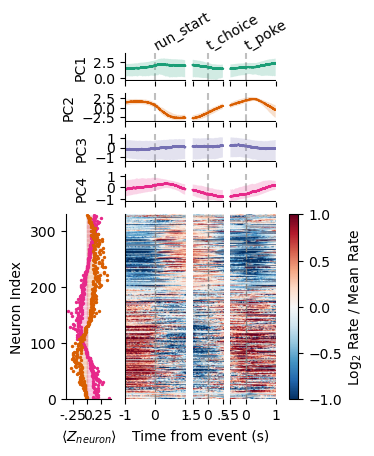

In [19]:


# group = trial_df
# n_plot = 4
# fig, ax_list = plt.subplots(nrows=n_plot, ncols=1, figsize=(2, 1*n_plot), sharex=True)

n_pcs=4
fig, ax = plt.subplots(ncols=3,nrows=n_pcs+1, width_ratios=[1.5,5,.3],height_ratios=[1] * n_pcs +[6.5], figsize=(3,4.5), sharey=False,
                       sharex="col")
heat_ax = ax[-1, 1]
val_ax = ax[-1, 0]
pc_ax = ax[:-1, 1]
cmap_ax = ax[-1, 2]

for a in ax[:-1, 0]:
    a.axis("off")
for a in ax[:-1, 2]:
    a.axis("off")

cached_results = {}

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    # for group, label, color in zip(condition_groups, condition_labels, condition_colors):
    mark_times = group[mark].values
    if len(mark_times) == 0:
        continue

    if mark in cached_results:
        results = cached_results[mark]
    else:
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        cached_results[mark] = results
    # results = results[:, ::2]

    # mid = np.nanmedian(results, axis=0)
    # lo = np.nanpercentile(results, 25, axis=0)
    # hi = np.nanpercentile(results, 75, axis=0)
    r = np.nanpercentile(results, [25, 50, 75], axis=0)
    mid = r[1]
    lo = r[0]
    hi = r[2]

    t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
    ind_mid = np.digitize(offset,t_plot)
    for i, ax in enumerate(pc_ax):
        # ax = fig.gca()
        color = plt.cm.Dark2(i/8)
        ax.plot(t_plot,mid[:, i], color=color)
        ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
        ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

        ax.spines[["top", "right"]].set_visible(False)
    # ax_2d.plot(mid[:, pcs_2d[0]], mid[:, pcs_2d[1]], label=label if mark == mark_list[0] else None, color=color)
    # ax_2d.scatter(mid[ind_mid, pcs_2d[0]], mid[ind_mid, pcs_2d[1]], facecolor='none',
    #               edgecolors="k", s=100, lw=2,zorder = 100)
    # if label == condition_labels[0]:
    #     # ax_2d.text(mid[ind_mid, pcs_2d[0]]* 1.3, mid[ind_mid, pcs_2d[1]] * 1.3, mark, ha="left", va="bottom")
    #     ax_2d.text(mid[ind_mid, pcs_2d[0]] +.4*np.sign(mid[ind_mid, pcs_2d[0]]),
    #                mid[ind_mid, pcs_2d[1]] + .4*(np.sign(mid[ind_mid, pcs_2d[1]])),
    #                mark, ha="center", va="center")


for pc,ax in enumerate(pc_ax):
    # ax = fig.gca()
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    ticks = []
    labels = []
    for mark, offset, range_val in zip(mark_list, offset_list, range_list):
        xx = np.array([
            range_val[0], 0, range_val[1]
        ])
        ticks.append(xx + offset)
        labels.append(["-.5" if range_val[0] ==-.5 else "-1",
                       "0",
                       ".5" if range_val[1] ==.5 else "1"
                       ])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, [])
    # ax.set_xlabel("Time from event (s)")

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    ax.set_ylabel(f"PC{pc+1}")


ax = pc_ax[0]
ylim_top = ax.get_ylim()[1]
for mark, offset in zip(mark_list, offset_list):
    ax.text(offset-.1, ylim_top * 0.99, mark, ha="left", va="bottom", rotation=30)
###########################
###########################
###########################
###########################
#SPIKING HEATMAP
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    v = compiled_results[mark]
    v = np.array(v)[0][ind_sorted, :]/rate_means[:,None]
    cm = heat_ax.imshow(np.log2(v), cmap ="RdBu_r", clim = (-1,1),aspect='auto',
               extent=[range_val[0]+offset, range_val[1]+offset, 0, len(ind_sorted)],
               rasterized=True)

heat_ax.set_xlim(range_list[0][0]+offset_list[0], range_list[-1][1]+offset_list[-1])


ticks = []
labels = []
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    xx = np.array([
        range_val[0], 0, range_val[1]
    ])
    ticks.append(xx + offset)
    labels.append(["-.5" if range_val[0] ==-.5 else "-1",
                    "0",
                    ".5" if range_val[1] ==.5 else "1"
                    ])
    heat_ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    heat_ax.axvline(offset, color="grey", linestyle="--", lw=1)
ticks = np.concatenate(ticks)
labels = np.concatenate(labels)
heat_ax.set_xticks(ticks, labels)
heat_ax.set_xlabel("Time from event (s)")
heat_ax.set_yticks([])
heat_ax.spines[["top", "right", "bottom"]].set_visible(False)
heat_ax.tick_params(axis = 'x', bottom=True, labelbottom=True, top=False, labeltop=False, )

# colorbar
cbar = plt.colorbar(cm, cax=cmap_ax)
cbar.set_label("Log$_2$ Rate / Mean Rate")

#############
# Z EMBEDDINGS
for i in range(ind_sorted.shape[0]):
    for i_pc, pc in enumerate(pc_inds):
        val_ax.scatter([z_neuron[ind_sorted[i],i_pc]],[i] , color=plt.cm.Dark2(pc/8), s=2,
                       zorder = -i_pc)
        val_ax.plot([0, z_neuron[ind_sorted[i],i_pc]],[i,i] , color=plt.cm.Dark2(pc/8),
                    linewidth=1,
                    alpha = .1,
                    zorder = -4)
val_ax.set_xlabel("$\langle Z_{neuron}\\rangle$")
val_ax.set_ylabel("Neuron Index")
val_ax.set_ylim(0, ind_sorted.shape[0])
val_ax.spines[["top", "right"]].set_visible(False)
val_ax.set_xticks([-0.25, 0, 0.25])
val_ax.set_xticklabels(["-.25", "0", ".25"])

heat_ax.set_ylim(0, ind_sorted.shape[0])

plt.rcParams["svg.fonttype"] = "none"
fig.savefig(fig_dir / f"task_progression_trial_structure.svg", bbox_inches="tight")


### Select data grouping

In [207]:
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]

##########################
### Regular categories
##########################
condition_type = "category"
condition_feature = "prev_trial_reward"
condition_values = _df[condition_feature].unique()
condition_values = condition_values[~np.isnan(condition_values)]
condition_groups = []
condition_labels = []
condition_colors = []

if condition_type == "category":
    for value in condition_values:
        condition_groups.append(_df[_df[condition_feature] == value])
        condition_labels.append(f"{condition_feature} = {value}")
        # condition_colors.append(f"C{len(condition_groups) - 1}")
        i_color = .1 if value == 0 else .9
        condition_colors.append(plt.cm.managua(i_color))

# ##########################
# ### N pre switch categories
# ##########################
# condition_type = "category"
# condition_feature = "n_pre_switch"
# condition_values = _df[condition_feature].unique()
# condition_values = [1,2,3,4,5,6,0]

# condition_groups = []
# condition_labels = []
# condition_colors = []
# if condition_type == "category":
#     for i, value in enumerate(condition_values):
#         condition_groups.append(_df[_df[condition_feature] == value])
#         condition_labels.append(f"{condition_feature} = {value}")
#         # condition_colors.append(plt.cm.plasma(value/len(condition_values)) if value else "r")
#         condition_colors.append(plt.cm.plasma(i/len(condition_values)) if value else "r")


# ##########################
# ### Range categories
# ##########################

# condition_type = "range"
# condition_feature = "Q_leaf_A_update"
# # percentiles = np.linspace(5,95,7)
# # condition_values = np.nanpercentile(_df[condition_feature], percentiles)
# # condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
# # condition_values = np.linspace(np.nanpercentile(_df[condition_feature], 5), 0, 4)
# # condition_values2= np.linspace(0, np.nanpercentile(_df[condition_feature], 95), 4)
# # condition_values = np.concatenate([condition_values, condition_values2[1:]])

# v = _df[condition_feature].values
# v = v[v<0]
# condition_values = np.linspace(np.nanpercentile(v, 5), 0, 6)
# v_hi = _df[condition_feature].values
# v_hi = v_hi[v_hi>0]
# condition_values_hi = np.linspace(0, np.nanpercentile(v_hi, 95), 6)
# condition_values = np.concatenate([condition_values, condition_values_hi[1:]])

# # condition_values  = condition_values[condition_values <= 0]
# condition_groups = []
# condition_labels = []
# condition_colors = []
# if condition_type == "range":
#     for i in range(len(condition_values) - 1):
#         condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
#         condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
#         color = np.mean(condition_values[i:i+2])
#         val_mids = (condition_values[1:] + condition_values[:-1]) / 2
#         color = color / np.max(np.abs(val_mids))
#         color += 1
#         color = color /2
#         condition_colors.append(plt.cm.managua(color))


# condition_type = "range"
# condition_feature = "Q_leaf_B"
# df = _df[_df.reward==1]
# percentiles = np.linspace(5,95,7)
# condition_values = np.nanpercentile(_df[condition_feature], percentiles)
# condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
# condition_groups = []
# condition_labels = []
# condition_colors = []
# if condition_type == "range":
#     for i in range(len(condition_values) - 1):
#         condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
#         condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
#         color = np.mean(condition_values[i:i+2])
#         val_mids = (condition_values[1:] + condition_values[:-1]) / 2
#         color = color - np.min(val_mids)
#         color = color / np.max(val_mids - np.min(val_mids))
#         color += 1
#         color = color /2
#         condition_colors.append(plt.cm.magma(color))

### Run

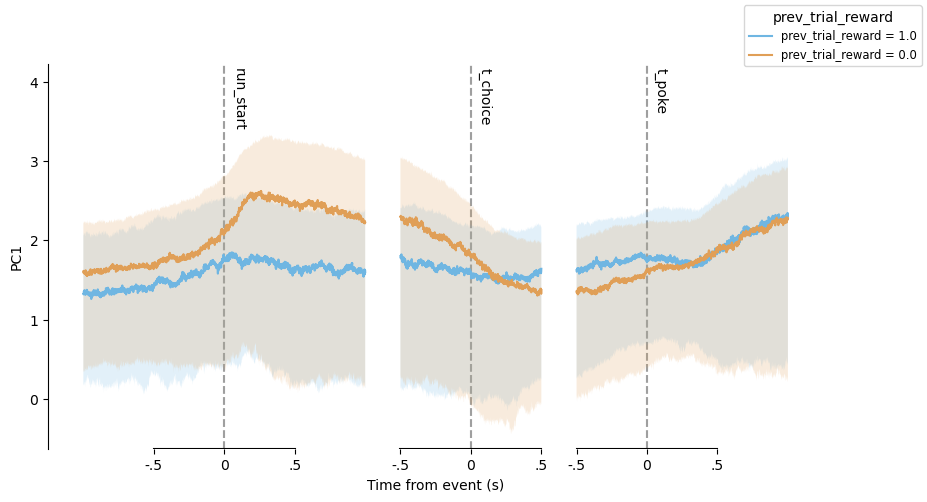

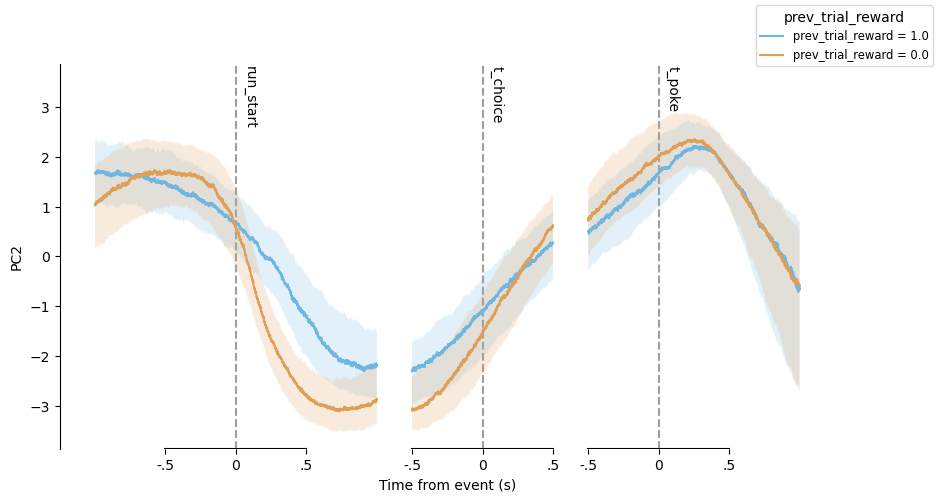

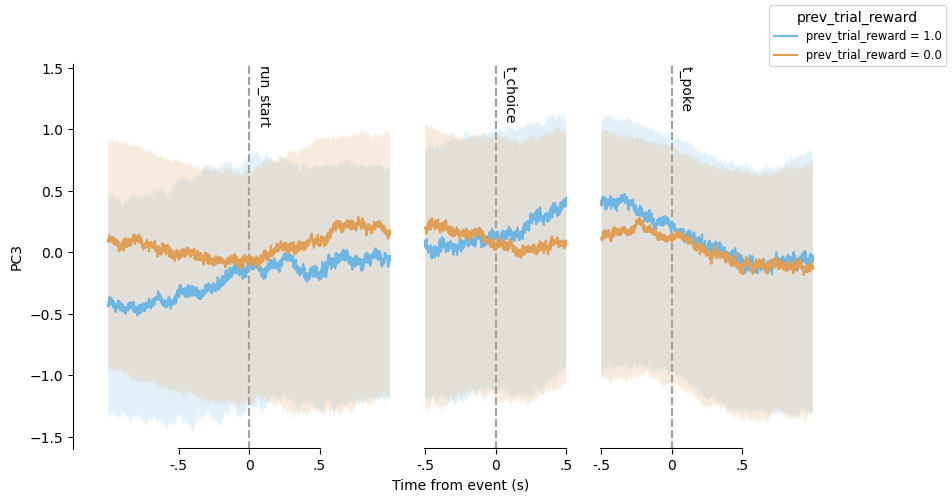

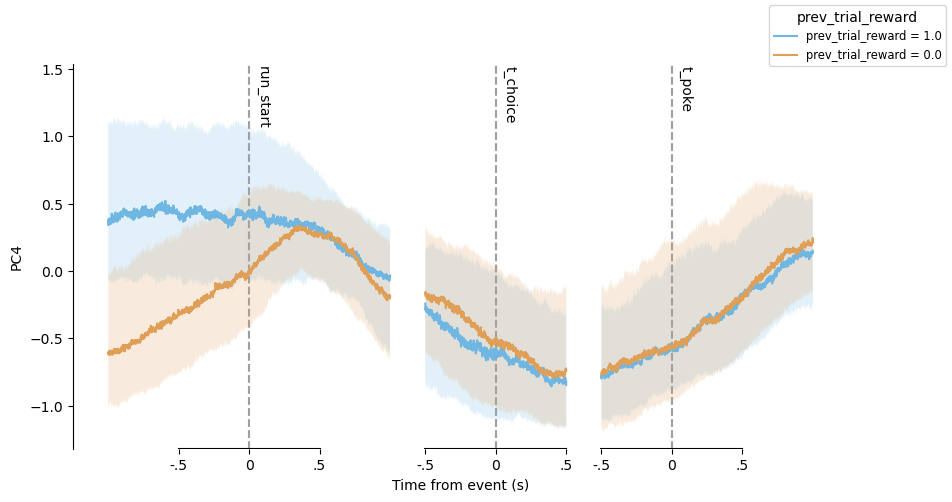

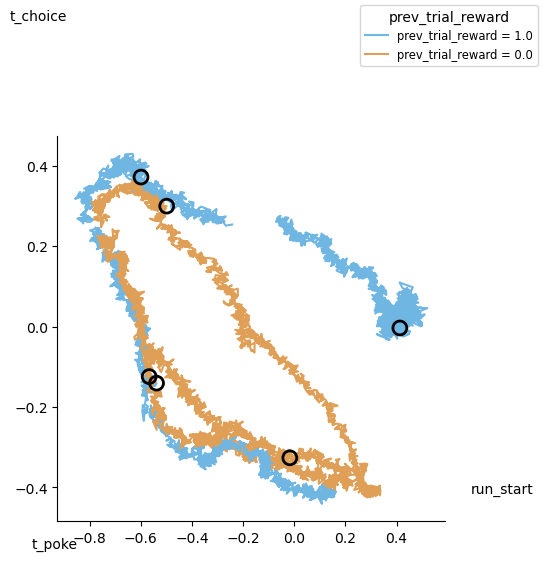

In [208]:
mark_list = ["t_poke_prev", "run_start", "t_choice", "t_poke", "t_out"]
offset_list = [-1.25, 0, 1.25, 2.5, 3.75]
range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 1)]

mark_list = ["t_poke_prev", "run_start", "t_choice",]
offset_list = [-1.25, 0, 1.25,]
range_list = [(-1, 1.5), (-0.5, 0.5), (-0.5, 0.5), ]

mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

n_plot = 4
figure_list = [plt.figure(figsize=(10, 5)) for _ in range(n_plot)]
fig_2d = plt.figure(figsize=(5, 5))
ax_2d = fig_2d.gca()
pcs_2d = [3,4]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        mark_times = group[mark].values
        if len(mark_times) == 0:
            continue
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        # results = results[:, ::2]

        # mid = np.nanmedian(results, axis=0)
        # lo = np.nanpercentile(results, 25, axis=0)
        # hi = np.nanpercentile(results, 75, axis=0)
        r = np.nanpercentile(results, [25, 50, 75], axis=0)
        mid = r[1]
        lo = r[0]
        hi = r[2]

        t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, fig in enumerate(figure_list):
            ax = fig.gca()
            ax.plot(t_plot,mid[:, i], label=label if mark == mark_list[0] else None, color=color)
            ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

        ax_2d.plot(mid[:, pcs_2d[0]], mid[:, pcs_2d[1]], label=label if mark == mark_list[0] else None, color=color)
        ax_2d.scatter(mid[ind_mid, pcs_2d[0]], mid[ind_mid, pcs_2d[1]], facecolor='none',
                      edgecolors="k", s=100, lw=2,zorder = 100)
        if label == condition_labels[0]:
            # ax_2d.text(mid[ind_mid, pcs_2d[0]]* 1.3, mid[ind_mid, pcs_2d[1]] * 1.3, mark, ha="left", va="bottom")
            ax_2d.text(mid[ind_mid, pcs_2d[0]] +.4*np.sign(mid[ind_mid, pcs_2d[0]]),
                       mid[ind_mid, pcs_2d[1]] + .4*(np.sign(mid[ind_mid, pcs_2d[1]])),
                       mark, ha="center", va="center")


for pc,fig in enumerate(figure_list):
    ax = fig.gca()
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

    ticks = []
    labels = []
    for mark, offset in zip(mark_list, offset_list):
        xx = np.array([-0.5, 0, 0.5])
        ticks.append(xx + offset)
        labels.append(["-.5", "0", ".5"])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)
    ax.set_xlabel("Time from event (s)")

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    ax.set_ylabel(f"PC{pc+1}")

fig_2d.legend(loc="outside right upper", fontsize="small", title=condition_feature)
ax_2d.spines[["top", "right",]].set_visible(False)

sub_dir = fig_dir/ f"{condition_feature}"
sub_dir.mkdir(parents=True, exist_ok=True)

# fig_2d.savefig(sub_dir / f"2d_plot_unrewarded.svg",)
# fig_2d.savefig(sub_dir / f"2d_plot_rewarded.svg",)

for pc,fig in enumerate(figure_list):
    fig.savefig(sub_dir / f"pc_{pc+1}.png", dpi=300, bbox_inches="tight")
    fig.savefig(sub_dir / f"pc_{pc+1}.svg")

### No split multi pc figure

In [131]:
np.nanstd(results, axis=0).shape, np.sqrt(np.sum(~np.isnan(results), axis=0)).shape, results.shape
np.unique(np.sqrt(np.sum(~np.isnan(results), axis=0)))

array([25.25866188])

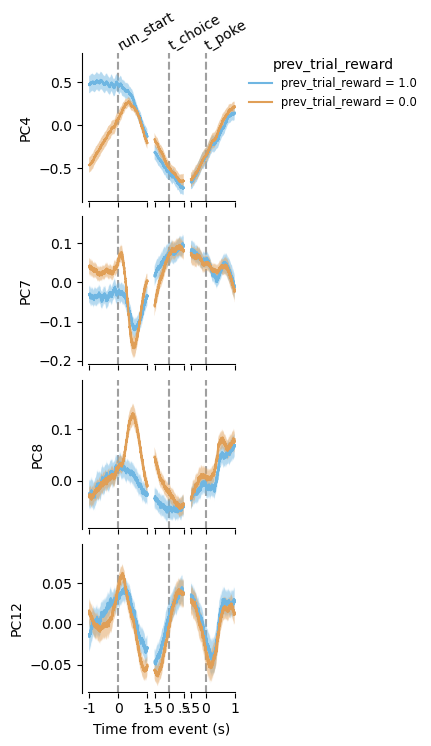

In [ ]:
mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

pc_to_plot = [3,6,7,11]


show_dist = True
dist = "sem" # "iqr"

fig, ax_list = plt.subplots(nrows=len(pc_to_plot), ncols=1, sharey="row", sharex=True, #figsize=(5, 1.875*len(pc_to_plot)))
                            figsize=(2,2*len(pc_to_plot)))


reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        # print(f"Processing {mark} for {label}")
        # for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            # group = group_full[group_full.prev_trial_reward == reward_val]


        mark_times = group[mark].values
        if len(mark_times) == 0:
            continue
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        # results = results[:, ::2]


        # mid = np.nanmedian(results, axis=0)
        # lo = np.nanpercentile(results, 25, axis=0)
        # hi = np.nanpercentile(results, 75, axis=0)

        if show_dist:
            if dist == "iqr":
                r = np.nanpercentile(results, [25, 50, 75], axis=0)
                mid = r[1]
                lo = r[0]
                hi = r[2]
            elif dist == "sem":
                mid = np.nanmean(results, axis=0)
                sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                lo = mid - sem
                hi = mid + sem

        else:
            mid = np.nanmean(results, axis=0)


        t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, pc in enumerate(pc_to_plot):
            # pc = pc_to_plot[i]
            ax = ax_list[i]#[i_ax]
            ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None, color=color)
            if show_dist:
                ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.5)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)


for i,pc in enumerate(pc_to_plot):
    ax = ax_list[i]
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    if i ==0:
        for mark, offset in zip(mark_list, offset_list):
            # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
            ax.text(offset -.1, ylim_top * 0.99, mark, ha="left", va="bottom", rotation=30)

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)

    ax.spines[["top", "right", "bottom"]].set_visible(False)


    ax.set_ylabel(f"PC{pc+1}")

fig.legend(loc="outside right upper", fontsize="small", title=condition_feature,
            bbox_to_anchor=(1.8, .9), borderaxespad=0., frameon=False)
ax_list[-1].set_xlabel("Time from event (s)")

sub_dir = fig_dir/ f"{condition_feature}"
sub_dir.mkdir(parents=True, exist_ok=True)
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.1, wspace=0)
fig.savefig(sub_dir / f"multi_pc_plot{'_sem'*(show_dist and dist == 'sem')}.svg")

# for pc,fig in enumerate(figure_list):
#     fig.savefig(sub_dir / f"pc_{pc+1}.png", dpi=300, bbox_inches="tight")
#     fig.savefig(sub_dir / f"pc_{pc+1}.svg")

In [125]:
sem

array([[0.06144996, 0.03841095, 0.04342883, ..., 0.00232439, 0.00231776,
        0.00202328],
       [0.0613411 , 0.03834544, 0.04335699, ..., 0.00230778, 0.00232164,
        0.00198895],
       [0.06154341, 0.03829016, 0.04338067, ..., 0.00234707, 0.00228275,
        0.00201095],
       ...,
       [0.07843794, 0.07041091, 0.0457652 , ..., 0.00266447, 0.00201991,
        0.00171704],
       [0.07885403, 0.07037625, 0.04585686, ..., 0.00267908, 0.0020458 ,
        0.00172357],
       [0.07885309, 0.07009148, 0.04598744, ..., 0.00269017, 0.00206021,
        0.00174457]], shape=(1500, 20))

### Split Reward

In [186]:
# ##########################
# ### Range categories
# ##########################
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
condition_type = "range"
condition_feature = "Q_leaf_A_update"
# percentiles = np.linspace(5,95,7)
# condition_values = np.nanpercentile(_df[condition_feature], percentiles)
# condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
# condition_values = np.linspace(np.nanpercentile(_df[condition_feature], 5), 0, 4)
# condition_values2= np.linspace(0, np.nanpercentile(_df[condition_feature], 95), 4)
# condition_values = np.concatenate([condition_values, condition_values2[1:]])

# v = _df[condition_feature].values
# v = v[v<0]
# condition_values = np.linspace(np.nanpercentile(v, 5), 0, 6)
# v_hi = _df[condition_feature].values
# v_hi = v_hi[v_hi>0]
# condition_values_hi = np.linspace(0, np.nanpercentile(v_hi, 95), 6)
# condition_values = np.concatenate([condition_values, condition_values_hi[1:]])

v = _df[condition_feature].values
v = v[v<0]
condition_values = np.linspace(np.nanpercentile(v, 5), 0, 4)
v_hi = _df[condition_feature].values
v_hi = v_hi[v_hi>0]
condition_values_hi = np.linspace(0, np.nanpercentile(v_hi, 95), 4)
condition_values = np.concatenate([condition_values, condition_values_hi[1:]])

# condition_values  = condition_values[condition_values <= 0]
condition_groups = []
condition_labels = []
condition_colors = []
if condition_type == "range":
    for i in range(len(condition_values) - 1):
        condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
        condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
        color = np.mean(condition_values[i:i+2])
        val_mids = (condition_values[1:] + condition_values[:-1]) / 2
        color = color / np.max(np.abs(val_mids))
        color += 1
        color = color /2
        condition_colors.append(plt.cm.managua(color))

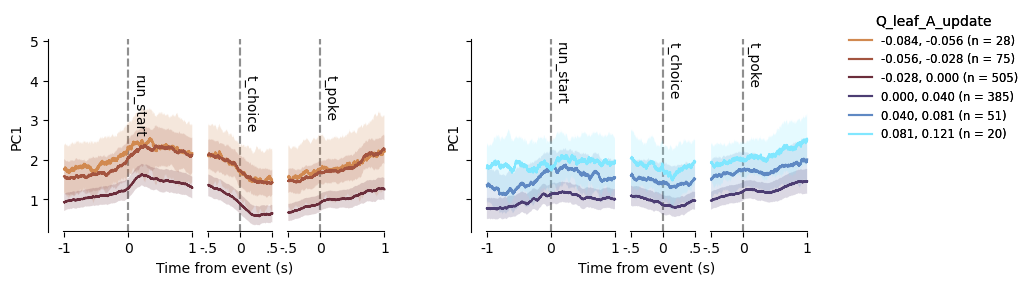

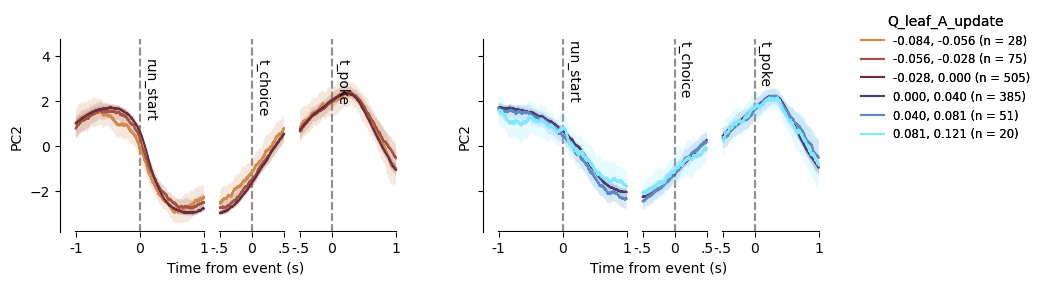

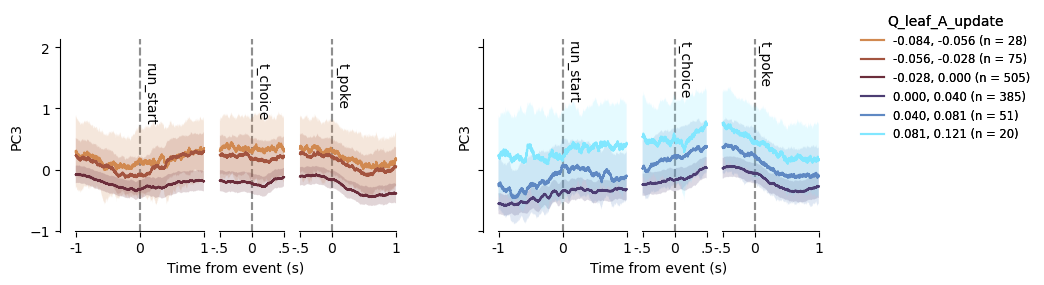

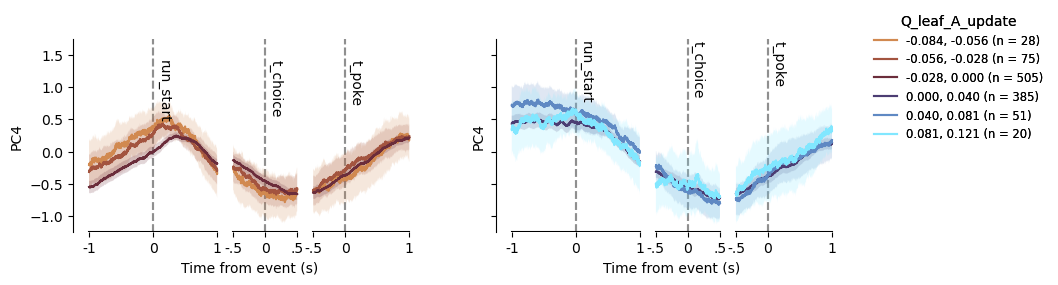

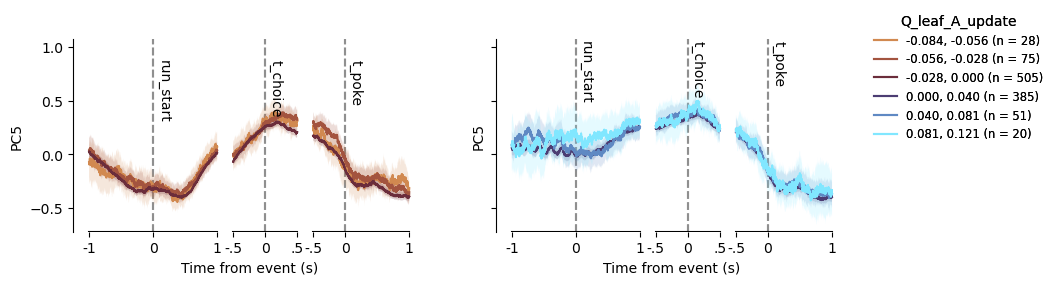

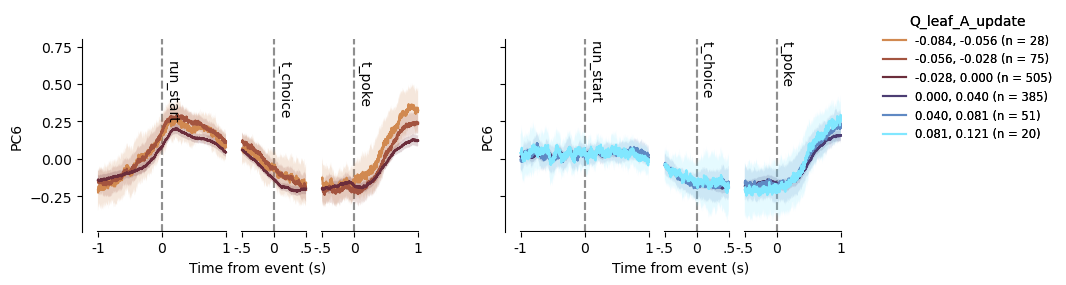

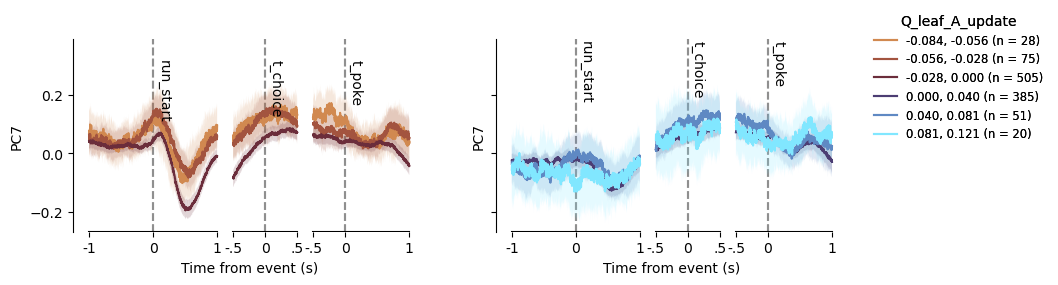

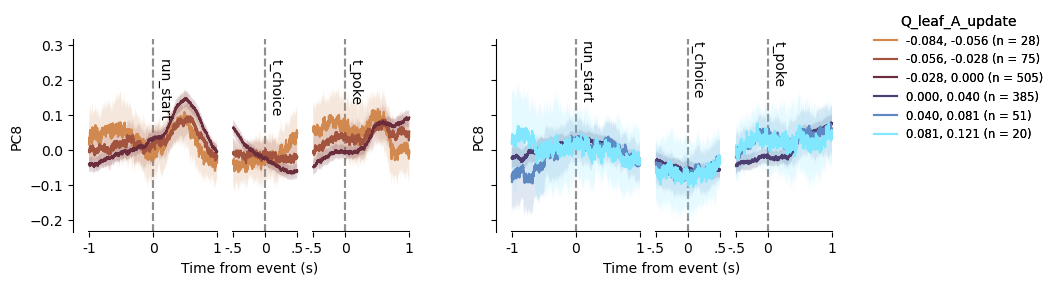

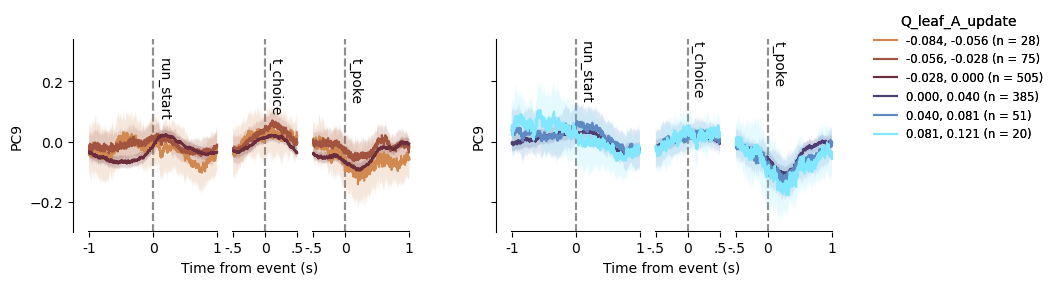

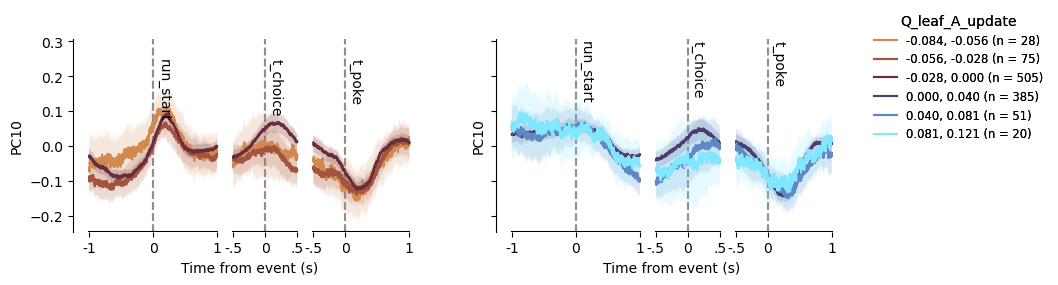

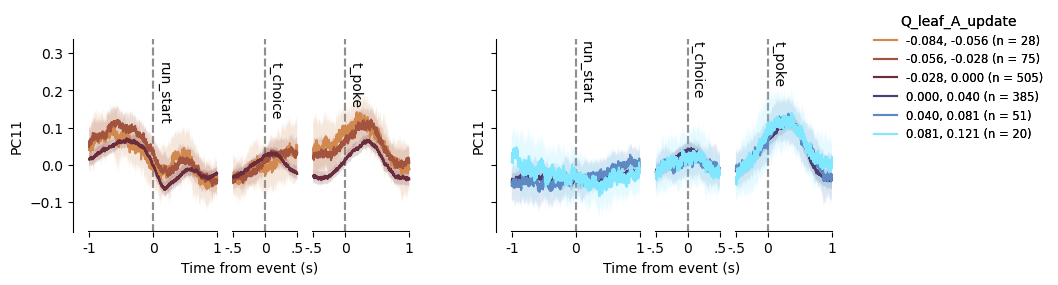

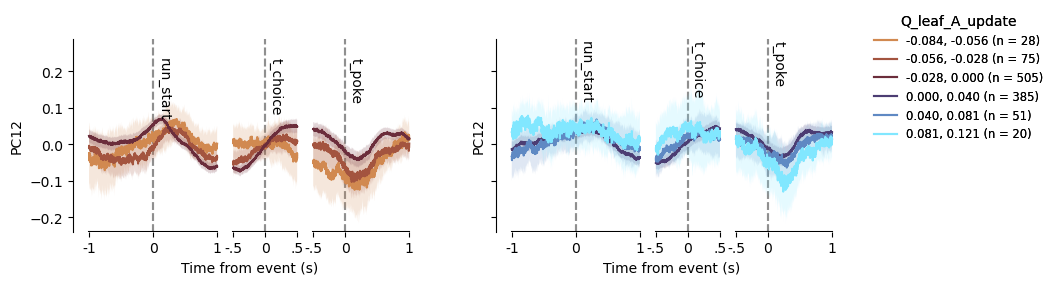

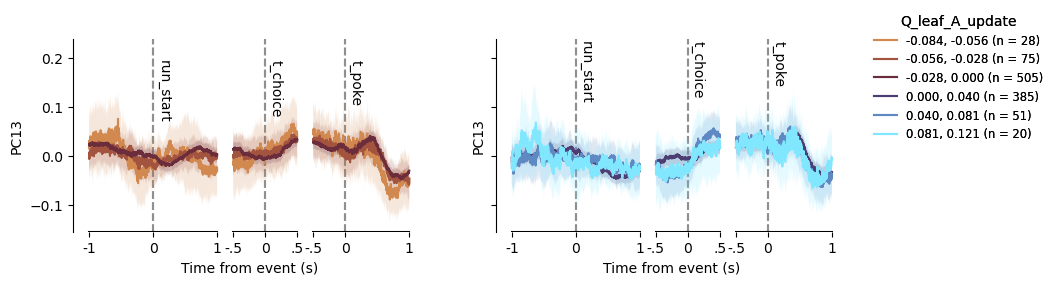

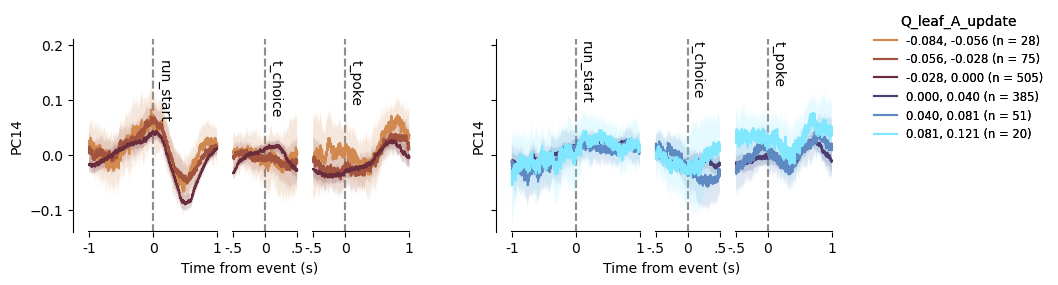

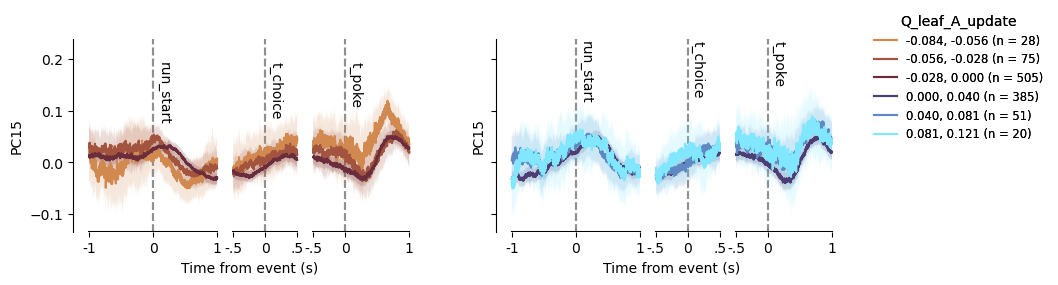

In [187]:
mark_list = ["t_poke_prev", "run_start", "t_choice", "t_poke", "t_out"]
offset_list = [-1.25, 0, 1.25, 2.5, 3.75]
range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 1)]

# mark_list = ["t_poke_prev", "run_start",]
# offset_list = [-6.5,0, ]
# range_list = [(-1, 3), (-3, 1), ]

# mark_list = ["t_poke_prev", "run_start", "t_choice",]
# offset_list = [-1.25, 0, 1.25,]
# range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), ]

mark_list =  ["run_start", "t_choice", "t_poke",]
offset_list = [-1.25, 0, 1.25, 2.5, 3.75]
range_list = [(-1, 0.6), (-0.6, 0.5), (-0.45, 1)]

mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]


show_dist = True
dist = "sem" # "iqr"
n_plot = 15
figure_list = []
ax_list = []
for pc in range(n_plot):
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
    figure_list.append(fig)
    ax_list.append(ax)


reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group_full, label, color in zip(condition_groups, condition_labels, condition_colors):
        # print(f"Processing {mark} for {label}")
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            # results = results[:, ::2]


            # mid = np.nanmedian(results, axis=0)
            # lo = np.nanpercentile(results, 25, axis=0)
            # hi = np.nanpercentile(results, 75, axis=0)

            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            for i, fig in enumerate(figure_list):
                ax = ax_list[i][i_ax]
                ax.plot(t_plot,mid[:, i], label=label if mark == mark_list[0] else None, color=color)
                if show_dist:
                    ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
                ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

        # ax_2d.plot(mid[:, pcs_2d[0]], mid[:, pcs_2d[1]], label=label if mark == mark_list[0] else None, color=color)
        # ax_2d.scatter(mid[ind_mid, pcs_2d[0]], mid[ind_mid, pcs_2d[1]], facecolor='none',
        #               edgecolors="k", s=100, lw=2,zorder = 100)
        # if label == condition_labels[0]:
        #     # ax_2d.text(mid[ind_mid, pcs_2d[0]]* 1.3, mid[ind_mid, pcs_2d[1]] * 1.3, mark, ha="left", va="bottom")
        #     ax_2d.text(mid[ind_mid, pcs_2d[0]] +.4*np.sign(mid[ind_mid, pcs_2d[0]]),
        #                mid[ind_mid, pcs_2d[1]] + .4*(np.sign(mid[ind_mid, pcs_2d[1]])),
        #                mark, ha="center", va="center")


for pc,fig in enumerate(figure_list):
    for i_ax, ax in enumerate(ax_list[pc]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1.2
        ax.set_ylim(ylim[0], ylim_top)

        for mark, offset in zip(mark_list, offset_list):
            ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)
        fig.legend(loc="outside right upper", fontsize="small", title=condition_feature,
               bbox_to_anchor=(1.1, 1), borderaxespad=0., frameon=False)

        ax.set_ylabel(f"PC{pc+1}")

sub_dir = fig_dir/ f"{condition_feature}"
sub_dir = sub_dir / "rewarded_unrewarded"
sub_dir.mkdir(parents=True, exist_ok=True)

# for pc,fig in enumerate(figure_list):
#     fig.savefig(sub_dir / f"pc_{pc+1}.png", dpi=300, bbox_inches="tight")
#     fig.savefig(sub_dir / f"pc_{pc+1}.svg")

### multipanel figure

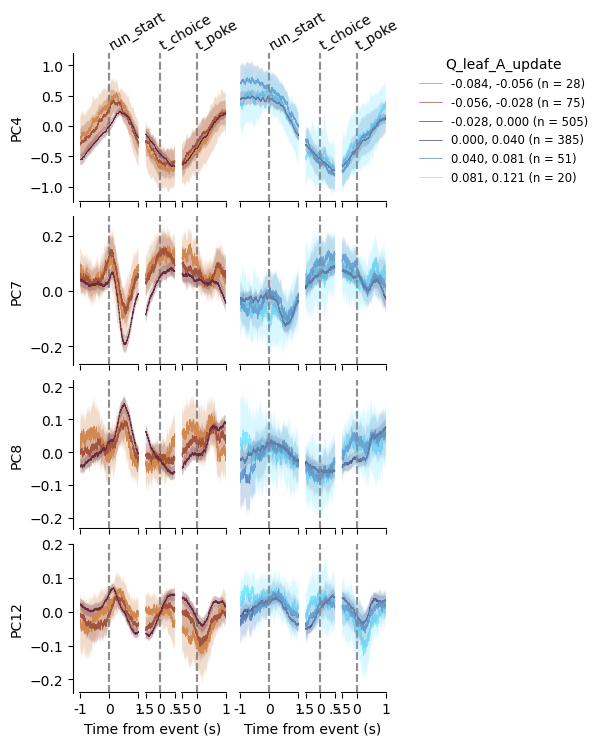

In [206]:
mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

pc_to_plot = [3,6,7,11]


show_dist = True
dist = "sem" # "iqr"


# n_plot = 20
# figure_list = []
# ax_list = []
# for pc in range(n_plot):
#     fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
#     figure_list.append(fig)
#     ax_list.append(ax)
fig, ax_list = plt.subplots(nrows=len(pc_to_plot), ncols=2, sharey="row", sharex=True, #figsize=(7.5, 1.875*len(pc_to_plot)))
                             figsize=(4, 2*len(pc_to_plot)))


reward_vals = [False, True]
reward_name = ["unrewarded", "rewarded"]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for i_group, (group_full, label, color) in enumerate(zip(condition_groups, condition_labels, condition_colors)):
        # print(f"Processing {mark} for {label}")
        for i_ax, (reward_val, reward_label) in enumerate(zip(reward_vals, reward_name)):
            group = group_full[group_full.prev_trial_reward == reward_val]


            mark_times = group[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            if results.shape[0] <10:
                continue
            # results = results[:, ::2]


            # mid = np.nanmedian(results, axis=0)
            # lo = np.nanpercentile(results, 25, axis=0)
            # hi = np.nanpercentile(results, 75, axis=0)

            if show_dist:
                if dist == "iqr":
                    r = np.nanpercentile(results, [25, 50, 75], axis=0)
                    mid = r[1]
                    lo = r[0]
                    hi = r[2]
                elif dist == "sem":
                    mid = np.nanmean(results, axis=0)
                    sem = np.nanstd(results, axis=0) / np.sqrt(np.sum(~np.isnan(results), axis=0)) * 3
                    lo = mid - sem
                    hi = mid + sem
            else:
                mid = np.nanmean(results, axis=0)


            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
            ind_mid = np.digitize(offset,t_plot)
            zorder = -i_group if reward_val else i_group
            for i, pc in enumerate(pc_to_plot):
                # pc = pc_to_plot[i]
                ax = ax_list[i][i_ax]
                ax.plot(t_plot,mid[:, pc], label=label if (mark == mark_list[0] and i ==0) else None,
                        zorder=zorder, color=color, lw= .5)
                if show_dist:
                    ax.fill_between(t_plot, lo[:, pc], hi[:, pc], facecolor=color, alpha=0.3, zorder = -1)
                ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)


for i,pc in enumerate(pc_to_plot):
    for i_ax, ax in enumerate(ax_list[i]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1#.2
        ax.set_ylim(ylim[0], ylim_top)

        if i ==0:
            for mark, offset in zip(mark_list, offset_list):
                # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
                 ax.text(offset - .1, ylim_top, mark, ha="left", va="bottom", rotation=30)

        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        if i == len(pc_to_plot) - 1:
            ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)


    ax_list[i][0].set_ylabel(f"PC{pc+1}")
    ax_list[i][1].spines["left"].set_visible(False)
    ax_list[i][1].yaxis.set_visible(False)
    # ax_list[i][1].set_yticks([])

    # if i == 0:
    #     ax_list[i][0].set_ylim(-1,1)
    #     continue
    # ax_list[i][0].set_ylim(-.22,.22)

fig.legend(
    loc="outside right upper", fontsize="small", title=condition_feature,
    bbox_to_anchor=(1.4, .9), borderaxespad=0., frameon=False
)
sub_dir = fig_dir/ f"{condition_feature}"
sub_dir = sub_dir / "rewarded_unrewarded"
sub_dir.mkdir(parents=True, exist_ok=True)
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.1, wspace=0)
fig.savefig(sub_dir / f"multi_pc_plot{'_sem' if show_dist and dist == 'sem' else ''}.svg")


## Firing rates

In [190]:
##########################
### Range categories
##########################
condition_type = "range"
condition_feature = "Q_leaf_A_update"
# percentiles = np.linspace(5,95,7)
# condition_values = np.nanpercentile(_df[condition_feature], percentiles)
# condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
# condition_values  = condition_values[condition_values <= 0]

_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
v = _df[condition_feature].values
v = v[v<0]
# condition_values = np.linspace(np.nanpercentile(v, 5), 0, 6)
# v_hi = _df[condition_feature].values
# v_hi = v_hi[v_hi>0]
# condition_values_hi = np.linspace(0, np.nanpercentile(v_hi, 95), 6)
# condition_values = np.concatenate([condition_values, condition_values_hi[1:]])
condition_values = np.linspace(np.nanpercentile(v, 5), 0, 4)
v_hi = _df[condition_feature].values
v_hi = v_hi[v_hi>0]
condition_values_hi = np.linspace(0, np.nanpercentile(v_hi, 95), 4)
condition_values = np.concatenate([condition_values, condition_values_hi[1:]])



condition_groups = []
condition_labels = []
condition_colors = []

for i in range(len(condition_values) - 1):
# for i in [0,2]:
    condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
    condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
    color = np.mean(condition_values[i:i+2])
    val_mids = (condition_values[1:] + condition_values[:-1]) / 2
    color = color / np.max(np.abs(val_mids))
    color += 1
    color = color /2
    condition_colors.append(plt.cm.managua(color))

len(condition_groups)

6

In [191]:
# mark_list = ["t_poke_prev", "run_start", "t_choice", "t_poke", "t_out"]
# offset_list = [-1.25, 0, 1.25, 2.5, 3.75]
# range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 1)]

# mark_list = [ "run_start", "t_choice", "t_poke", ]
# offset_list = [ 0, 1.25, 2.5, ]
# range_list = [ (-1, 0.5), (-0.5, 0.5), (-0.5, 1)]

mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

# mark_list = ["run_start"]
# offset_list = [0]
# range_list = [(-1, 2)]


compiled_results = {m:[] for m in mark_list}
compiled_results_per_trial = {m:[] for m in mark_list}
compiled_values_per_trial = {m:[] for m in mark_list}
from scipy.ndimage import gaussian_filter1d

bin_size = 0.05
sig_smooth = 0.1

# bin_size = .1
from tqdm import tqdm
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        t_bins_seg = np.arange(*range_val, bin_size)
        results = np.zeros((len(spikes), len(t_bins_seg) - 1))
        results_per_trial = np.zeros((len(spikes), len(t_bins_seg) - 1, len(group)))
        trial_marks = group[mark]
        for i_mark, m in enumerate(tqdm(trial_marks)):
            # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins_reward + m, smoothing_sigma=.01)
            # results.append(rates)
            for i, s in enumerate(spikes):
                st = np.searchsorted(s, m + t_bins_seg[0])
                en = np.searchsorted(s, m + t_bins_seg[-1])
                if en <= st:
                    continue
                delays = s[st:en] - m
                v = np.histogram(delays, bins=t_bins_seg)[0]

                v = v / (len(trial_marks) * bin_size)
                # v = smooth_signal(v, sig_smooth, bin_size)
                # v = gaussian_filter1d(v, sig_smooth/bin_size)
                results[i, :] += v
                results_per_trial[i, :, i_mark] = v
        results = np.array(results)
        results = gaussian_filter1d(results, sig_smooth/bin_size, axis=1)
        compiled_results[mark].append(results)
        compiled_results_per_trial[mark].append(results_per_trial)
        compiled_values_per_trial[mark].append(group[condition_feature].values)

100%|██████████| 20/20 [00:00<00:00, 98.64it/s]


In [192]:
pc_list = np.array([4,3])
pc_list = np.array([1,3])
# pc_list = np.array([1,5])

thresh = .45

z_mag_tot = np.linalg.norm(z_neuron[:, :], axis=1)
z_mag = np.linalg.norm(z_neuron[:, pc_list], axis=1)
z_angle = np.arctan2(z_neuron[:, pc_list[1]], z_neuron[:, pc_list[0]])

ind_sig = np.where(np.abs(z_neuron[:,pc_list]) > thresh)[0]

ind_sig = np.where((z_mag/z_mag_tot) > 0.4)[0]

ind_sort = ind_sig[np.argsort(z_neuron[ind_sig,pc_list[0]])]
ind_sort = ind_sig[np.argsort(z_angle[ind_sig])]


# angle_bins = np.linspace(-np.pi, np.pi, 21)
# ind_sig = []
# for i in range(len(angle_bins) - 1):
#     ind = np.where((z_angle > angle_bins[i]) & (z_angle <= angle_bins[i+1]))[0]
#     thresh_bin = np.percentile(z_mag[ind], 80)
#     ind_sig_i = ind[z_mag[ind] > thresh_bin]
#     print(ind_sig_i.size)
#     ind_sig.extend(ind_sig_i)
# ind_sig = np.array(ind_sig)
# ind_sort = ind_sig[np.argsort(z_angle[ind_sig])]


plt.scatter(z_neuron[:, pc_list[0]], z_neuron[:, pc_list[1]],color="grey")
plt.scatter(z_neuron[ind_sig, pc_list[0]], z_neuron[ind_sig, pc_list[1]], c=z_angle[ind_sig],)

IndexError: index 3 is out of bounds for axis 1 with size 2

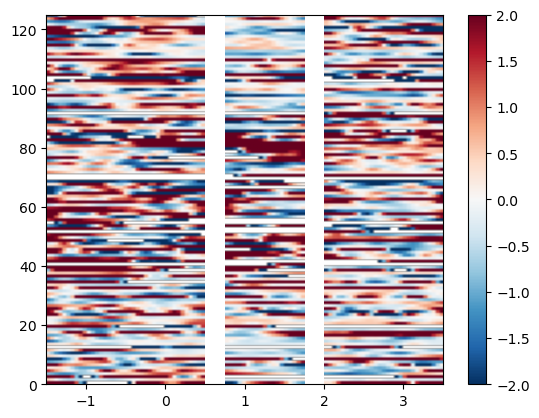

In [21]:
# pc_to_plot = 6
# thresh = .1

# # z_neuron = np.array([xx for xx in sorted_df.z_neuron.values])
# ind_sig = np.where(np.abs(z_neuron[:,pc_to_plot]) > thresh)[0]
# ind_sort = ind_sig[np.argsort(z_neuron[ind_sig,pc_to_plot])]





# z_samp = z_neuron[:, pc_list]
# z_mag = np.linalg.norm(z_neuron, axis=1)
# z_angle = np.arctan2(z_neuron[:, 1], z_neuron[:, 0])
# ind_sig = np.where(np.abs(z_samp) > thresh)[0]
# ind_sort = ind_sig[np.argsort(z_angle[ind_sig])]


# mark_list = [ "run_start", "t_choice", "t_poke"]
# offset_list = [ 0, 1.25, 2.5,]
# range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5,1)]

# ind_sort = np.arange(len(spikes))
# results = compiled_results["t_choice"]
# val = results[comp[0]][ind_sort,:] / (results[comp[1]][ind_sort,:]+.001)
# ind_sort = np.argsort(val.mean(axis=1))


fig = plt.figure()
ax = fig.gca()
comp = 0,-1
min_lim = 0
max_lim = 0
rng = 2

val_list = []
for mark, offset, range_val, results in zip(mark_list, offset_list, range_list, compiled_results.values()):
    # section_mean = compiled_avg[mark]
    # val = section_mean[ind_sort, :]
    val = results[comp[0]][ind_sort,:] / (results[comp[1]][ind_sort,:]+.001)
    # val = results[5]#/(results[comp[1]]+.001)
    # val = val[ind_sort,:]

    # val = val / np.mean(val, axis=1, keepdims=True)
    val = np.log2(val)
    # val = val - np.mean(val, axis=1, keepdims=True)
    cm = ax.imshow(val,
                   cmap="RdBu_r",
                   clim = (-rng,rng),
                   aspect="auto", extent=[range_val[0]+offset, range_val[1]+offset, 0, len(ind_sort)], origin="lower")
    val_list.append(val)
    min_lim = min(min_lim, offset + range_val[0])
    max_lim = max(max_lim, offset + range_val[1])

ax.set_xlim(min_lim, max_lim)
plt.colorbar(cm, ax=ax,)


## Spiking traces 

In [18]:
min_marks = []
for result_list in compiled_results.values():
    xx = np.array([np.sum(r, axis=1) for r in result_list])
    min_marks.append(xx)
    print(result_list[0].shape)
len(min_marks)

(497, 14)
(497, 9)
(497, 14)


3

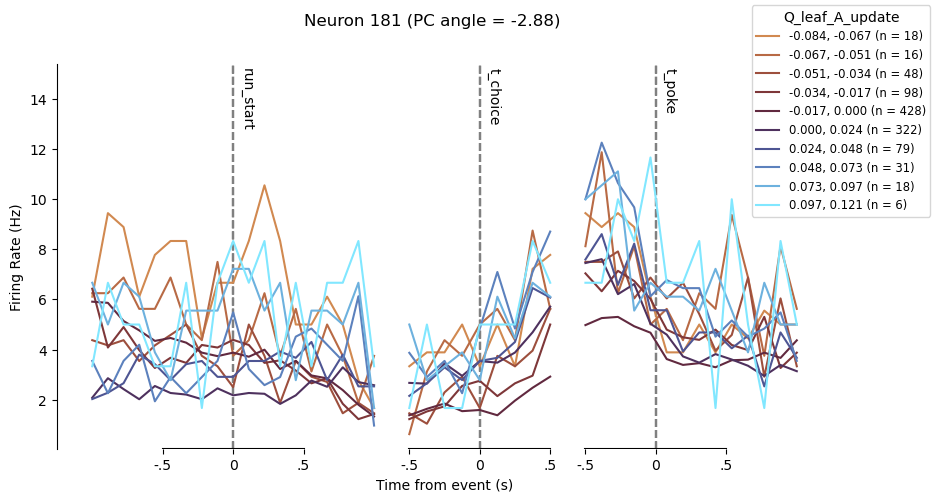

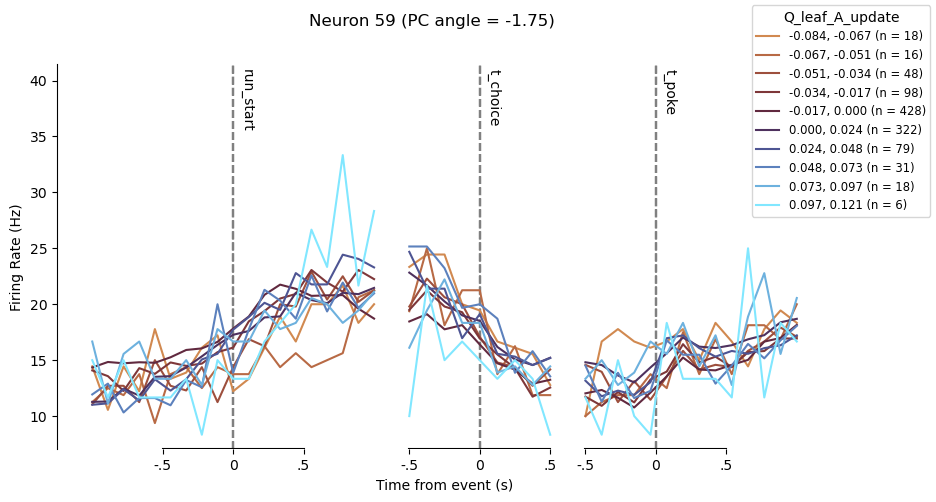

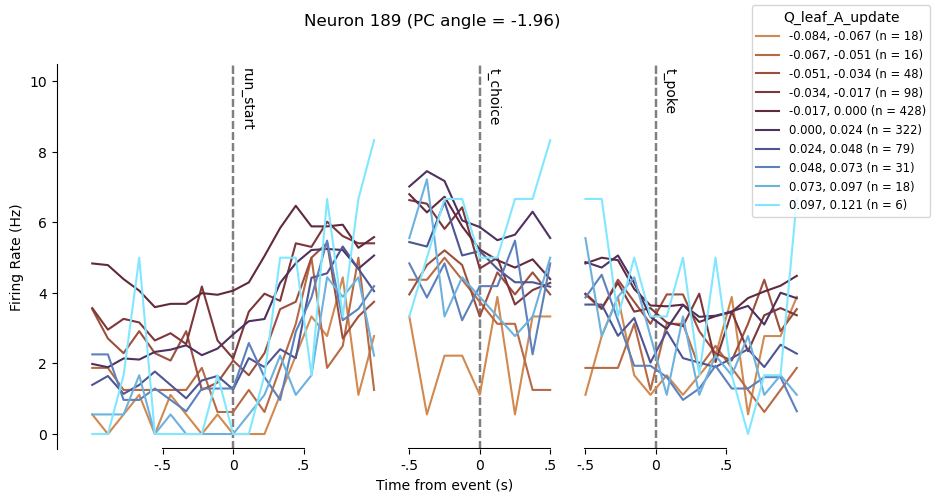

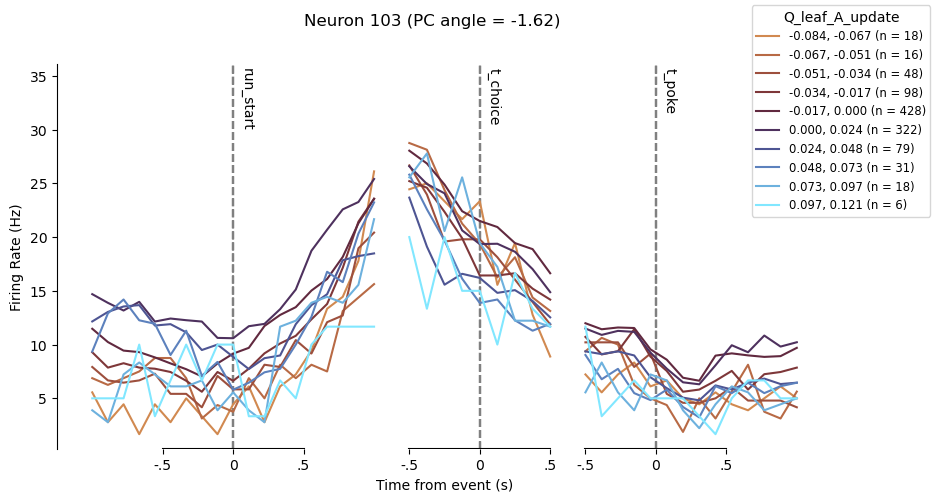

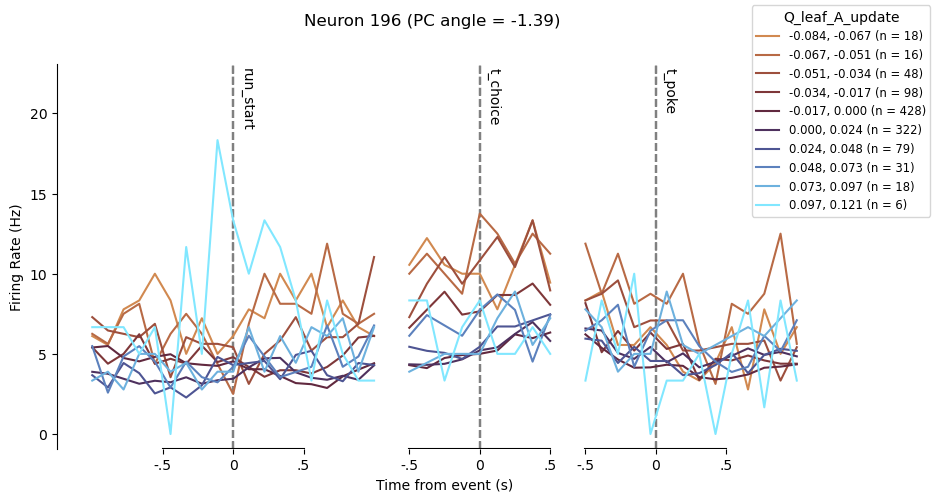

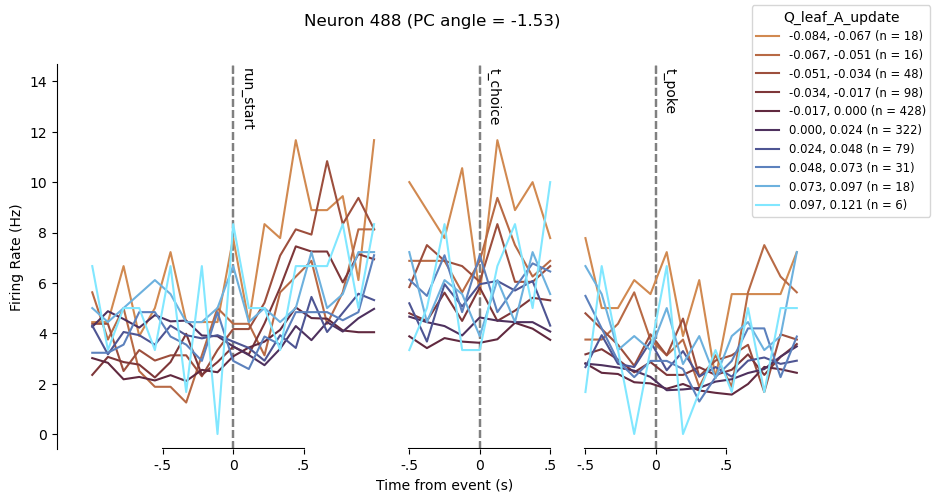

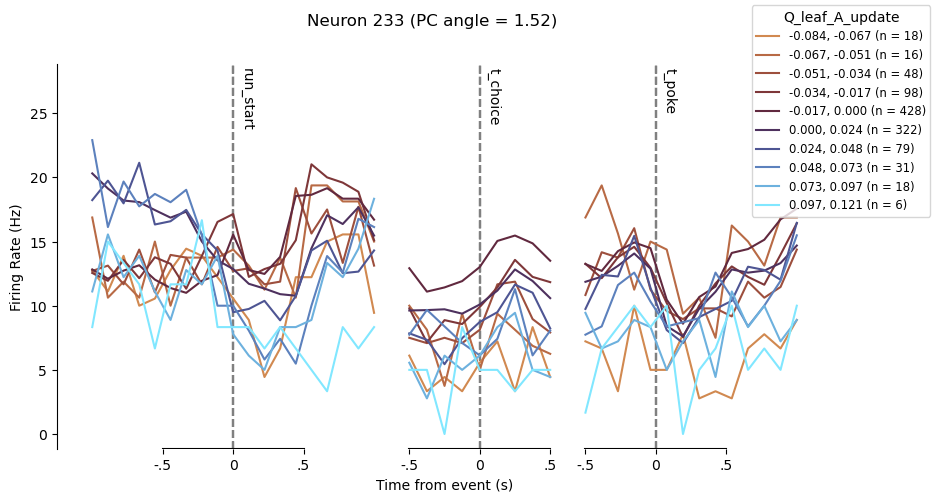

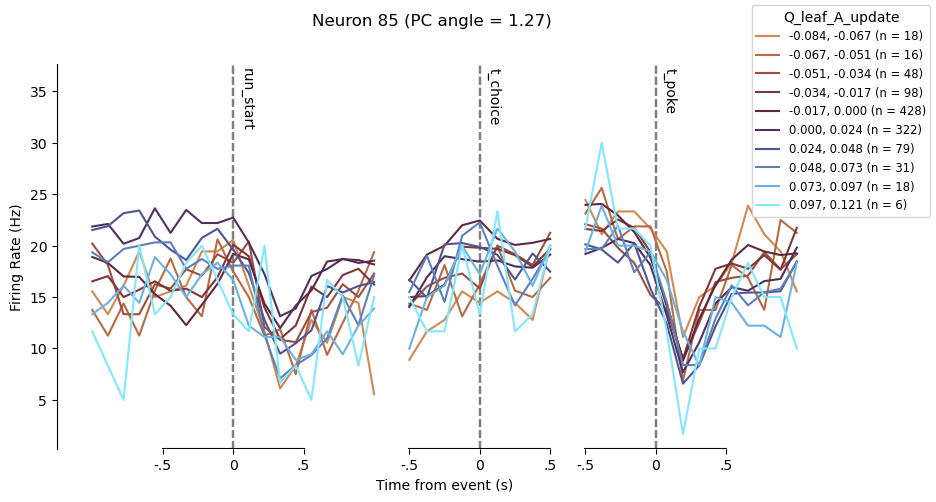

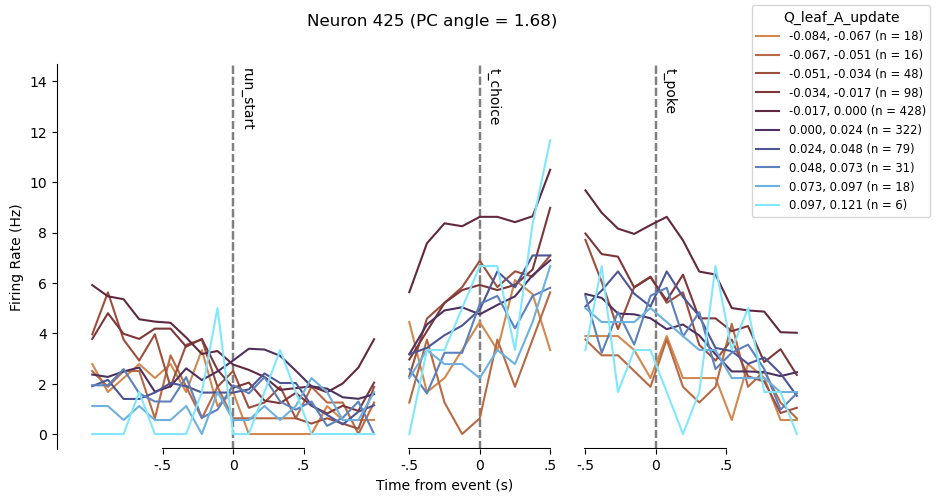

In [13]:
n_plot = 20

# neurons_to_plot = ind_sort
neurons_to_plot = [181, 59, 189, 103, 196, 488, 233, 85, 425, ]


n_plot = len(neurons_to_plot)

# neurons_to_plot = np.random.choice(ind_sort, size=n_plot, replace=False)
# neurons_to_plot = ind_sort[:n_plot]
figure_list = [plt.figure(figsize=(10, 5)) for _ in range(n_plot)]

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, fig in enumerate(figure_list):
            ax = fig.gca()
            ax.plot(t_plot,result[neurons_to_plot[i]], label=label if mark == mark_list[0] else None, color=color)
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)



for pc,fig in enumerate(figure_list):
    ax = fig.gca()
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

    ticks = []
    labels = []
    for mark, offset in zip(mark_list, offset_list):
        xx = np.array([-0.5, 0, 0.5])
        ticks.append(xx + offset)
        labels.append(["-.5", "0", ".5"])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)
    ax.set_xlabel("Time from event (s)")

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    ax.set_ylabel("Firing Rate (Hz)")
    fig.suptitle(f"Neuron {neurons_to_plot[pc]} (PC angle = {z_angle[neurons_to_plot[pc]]:.2f})")



## Split reward-no reward

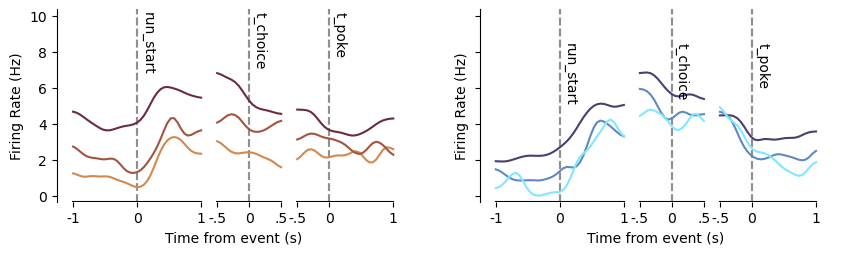

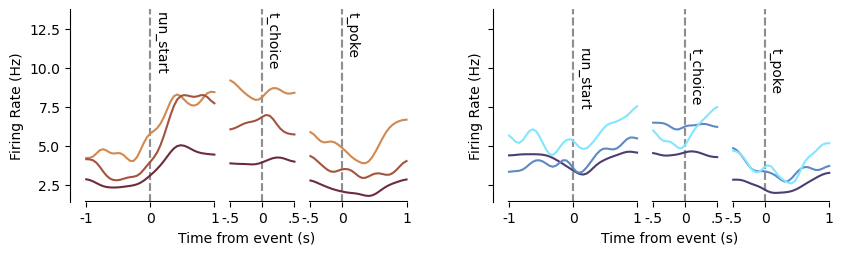

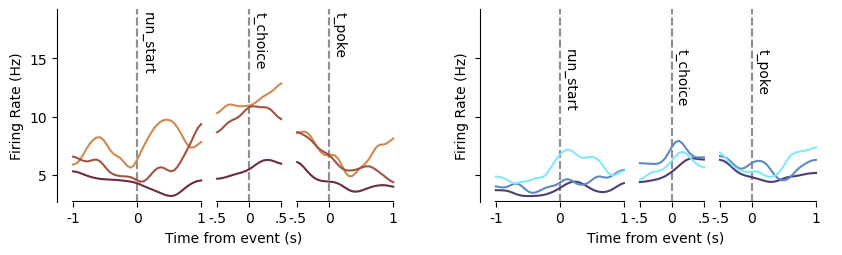

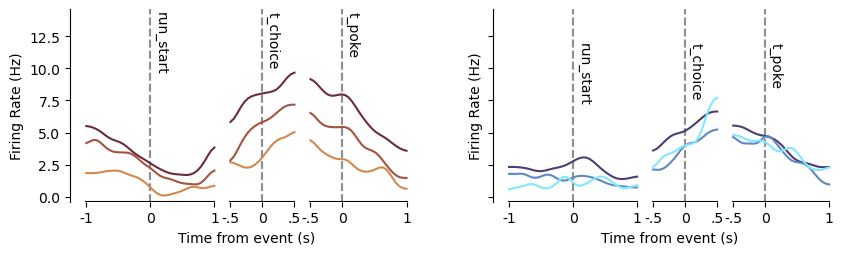

In [195]:


# neurons_to_plot = ind_sort
neurons_to_plot = [181, 59, 189, 103, 196, 488, 233, 85, 425, ]
# neurons_to_plot = [ 42,  49,  66,  78,  85, 101, 105, 115, 132, 137, 141, 142, 145,
#        149, 159, 181, 196, 200, 206, 223, 237, 246, 253, 258, 264, 267,
#        270, 279, 282, 288, 292, 320, 322, 323, 326, 330, 351, 355, 359,
#        360, 363, 405, 425, 428, 443, 451, 453, 457, 467, 468, 484, 488]
neurons_to_plot = [189,488,196 ,425]

n_plot = len(neurons_to_plot)

# neurons_to_plot = np.random.choice(ind_sort, size=n_plot, replace=False)
# neurons_to_plot = ind_sort[:n_plot]
# figure_list = [plt.figure(figsize=(10, 5)) for _ in range(n_plot)]
figure_list = []
ax_reward_list = []
ax_unreward_list = []
for i in range(n_plot):
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
    figure_list.append(fig)
    ax_reward_list.append(ax[1])
    ax_unreward_list.append(ax[0])

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, fig in enumerate(figure_list):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                ax = ax_reward_list[i]
            else:
                ax = ax_unreward_list[i]
            ax.plot(t_plot,result[neurons_to_plot[i]], label=label if mark == mark_list[0] else None, color=color)
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

for ax in ax_reward_list + ax_unreward_list:
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)
    ax.set_xlabel("Time from event (s)")

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.set_ylabel("Firing Rate (Hz)")


sub_dir = fig_dir/ f"{condition_feature}"
sub_dir = sub_dir / "firing_rates"
sub_dir = sub_dir / "rewarded_unrewarded"
sub_dir.mkdir(parents=True, exist_ok=True)
# for i,fig in enumerate(figure_list):

    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature,
    #            bbox_to_anchor=(1.1, 1), borderaxespad=0., frameon=False)
    # fig.suptitle(f"Neuron {neurons_to_plot[i]} (PC angle = {z_angle[neurons_to_plot[i]]:.2f})")

    # fig.savefig(sub_dir / f"neuron_{neurons_to_plot[i]}.png", dpi=300, bbox_inches="tight")
    # fig.savefig(sub_dir / f"neuron_{neurons_to_plot[i]}.svg",  bbox_inches="tight")


### multi-neuron plot

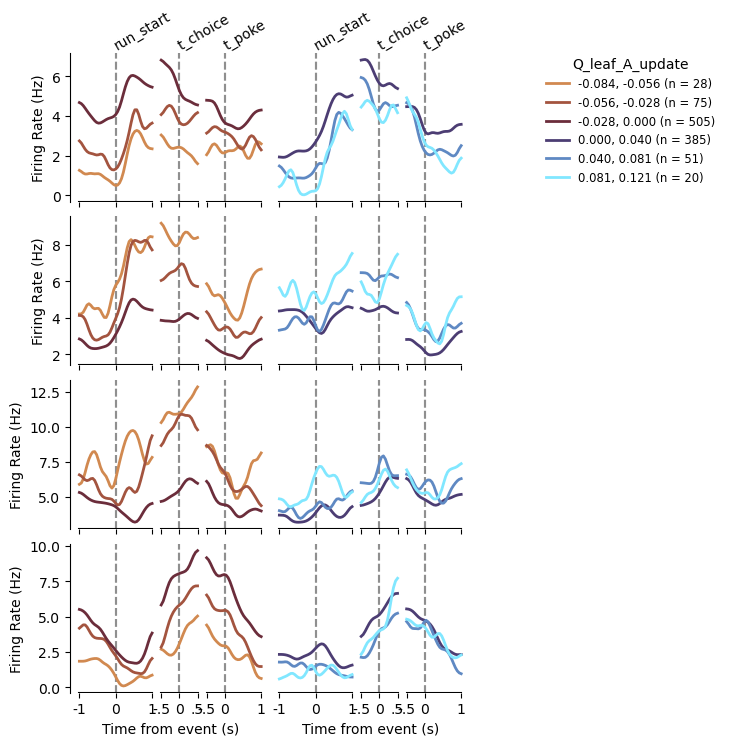

In [204]:


# neurons_to_plot = ind_sort
neurons_to_plot = [181, 59, 189, 103, 196, 488, 233, 85, 425, ]
# neurons_to_plot = [ 42,  49,  66,  78,  85, 101, 105, 115, 132, 137, 141, 142, 145,
#        149, 159, 181, 196, 200, 206, 223, 237, 246, 253, 258, 264, 267,
#        270, 279, 282, 288, 292, 320, 322, 323, 326, 330, 351, 355, 359,
#        360, 363, 405, 425, 428, 443, 451, 453, 457, 467, 468, 484, 488]
neurons_to_plot = [189,488,196 ,425]

n_plot = len(neurons_to_plot)

# neurons_to_plot = np.random.choice(ind_sort, size=n_plot, replace=False)
# neurons_to_plot = ind_sort[:n_plot]
# figure_list = [plt.figure(figsize=(10, 5)) for _ in range(n_plot)]
figure_list = []
ax_reward_list = []
ax_unreward_list = []
fig, ax_list = plt.subplots(nrows=n_plot, ncols=2, sharex=True,sharey="row", #figsize=(7.5, 1.875*n_plot))
                            figsize = (5, 2*n_plot) )
ax_reward_list = ax_list[:,1]
ax_unreward_list = ax_list[:,0]

# for i in range(n_plot):
#     fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 2.5))
#     figure_list.append(fig)
#     ax_reward_list.append(ax[1])
#     ax_unreward_list.append(ax[0])

for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result = compiled_results[mark][i_group]

        t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
        ind_mid = np.digitize(offset,t_plot)
        for i, neuron in enumerate(neurons_to_plot):
            # ax = fig.gca()
            if group.prev_trial_reward.any():
                ax = ax_reward_list[i]
            else:
                ax = ax_unreward_list[i]
            ax.plot(
                t_plot,
                result[neurons_to_plot[i]],
                label=label if (mark == mark_list[0] and i == 0) else None,
                color=color,
                lw=2
            )
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

for i,pc in enumerate(neurons_to_plot):
    for j, ax in enumerate([ax_unreward_list[i], ax_reward_list[i]]):
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1#.2
        ax.set_ylim(ylim[0], ylim_top)

        if i ==0:
            for mark, offset in zip(mark_list, offset_list):
                # ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
                ax.text(offset - .1, ylim_top, mark, ha="left", va="bottom", rotation=30)
        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx = np.array([lo, 0, hi])
            ticks.append(xx + offset)
            labels.append([lo_txt, "0", hi_txt])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        if i ==len(neurons_to_plot) - 1:
            ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)
        if j ==0:
            ax.set_ylabel("Firing Rate (Hz)")

for a in ax_reward_list:
    a.spines["left"].set_visible(False)
    a.yaxis.set_visible(False)

fig.legend(loc="outside right upper", fontsize="small", title=condition_feature,
         bbox_to_anchor=(1.4, .9), borderaxespad=0., frameon=False)
sub_dir = fig_dir/ f"{condition_feature}"
sub_dir = sub_dir / "firing_rates"
sub_dir = sub_dir / "rewarded_unrewarded"
sub_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(sub_dir / f"multi_neuron_plot.svg", bbox_inches="tight")
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.1, wspace=0)
# for i,fig in enumerate(figure_list):

#     fig.legend(loc="outside right upper", fontsize="small", title=condition_feature,
#                bbox_to_anchor=(1.1, 1), borderaxespad=0., frameon=False)
#     fig.suptitle(f"Neuron {neurons_to_plot[i]} (PC angle = {z_angle[neurons_to_plot[i]]:.2f})")

#     fig.savefig(sub_dir / f"neuron_{neurons_to_plot[i]}.png", dpi=300, bbox_inches="tight")
#     fig.savefig(sub_dir / f"neuron_{neurons_to_plot[i]}.svg",  bbox_inches="tight")


In [ ]:
W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T

# Stat Testing

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  608
Model:                            GLM   Df Residuals:                      607
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                       0.0090986
Method:                          IRLS   Log-Likelihood:                 566.47
Date:                Tue, 21 Jul 2026   Deviance:                       5.5229
Time:                        09:40:46   Pearson chi2:                     5.52
No. Iterations:                     3   Pseudo R-squ. (CS):            0.06051
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -1.3750      0.223     -6.160      0.0

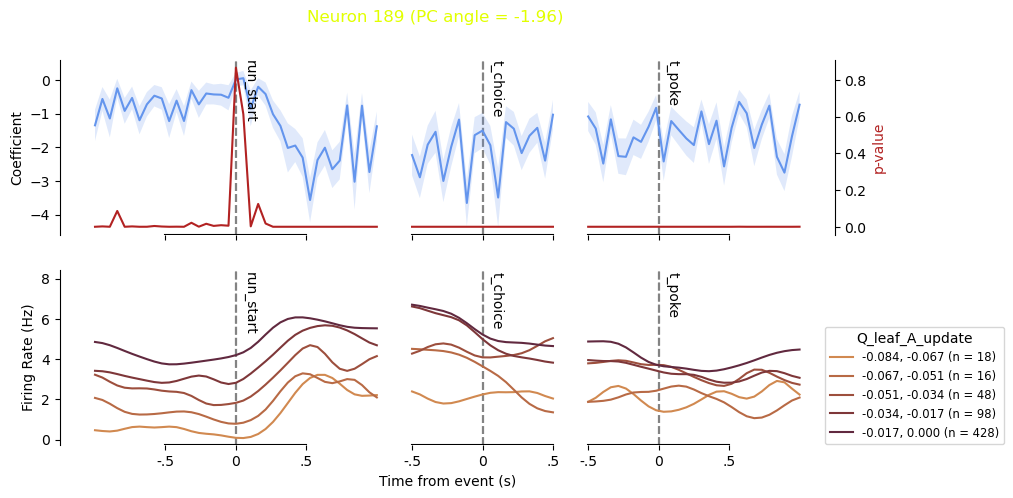

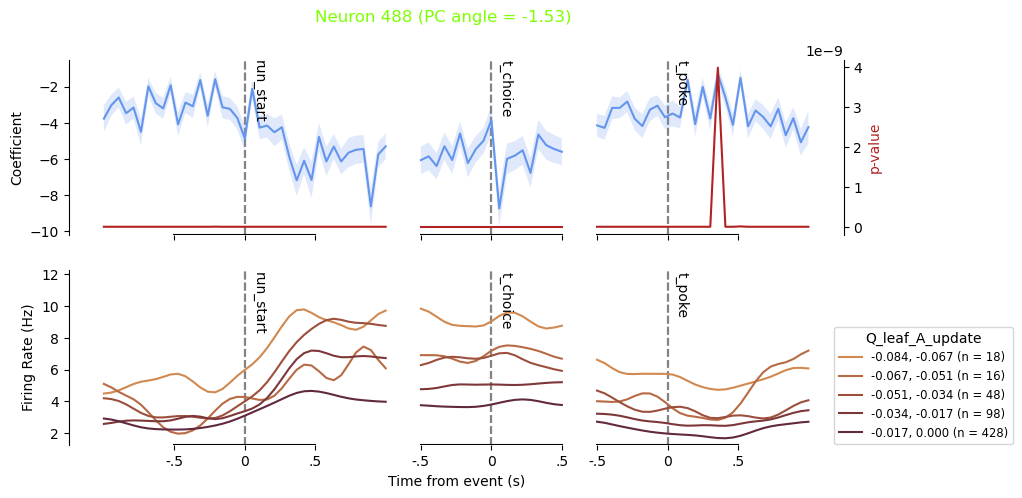

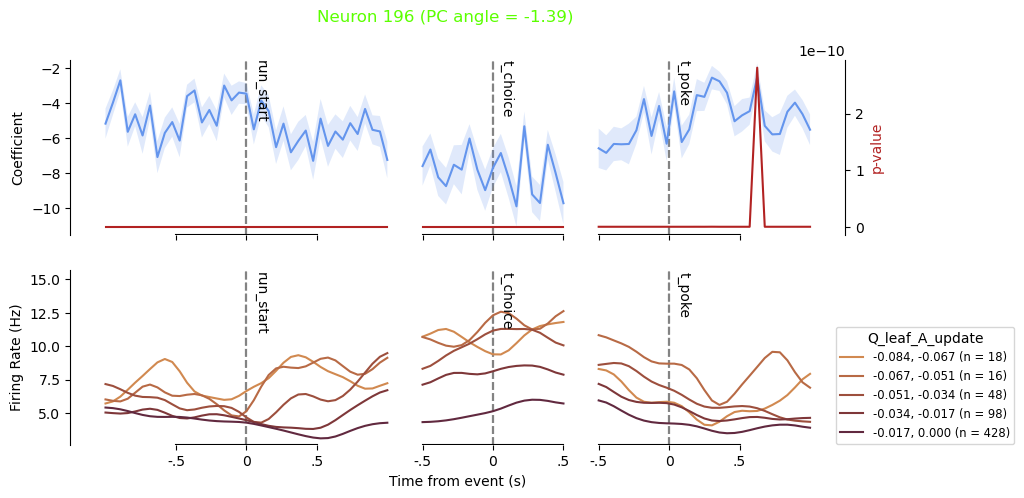

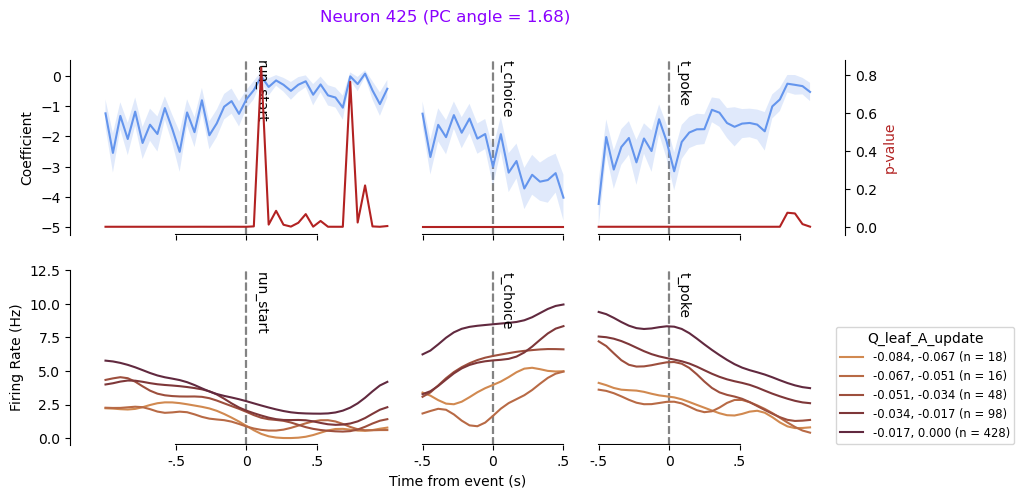

In [33]:
neuron_id = 488
# neuron_id = 425

neurons_to_plot = np.array([181, 59, 189, 103, 196, 488, 233, 85, 425])
neurons_to_plot = [189,488,196 ,425]


for neuron_id in neurons_to_plot:

    fig,ax_list = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 5))
    coff_ax = ax_list[0]
    p_ax = coff_ax.twinx()
    rate_ax = ax_list[1]

    for mark, offset, range_val in zip(mark_list, offset_list, range_list, ):
        result_per_trial = []
        values_per_trial = []
        sample_weights = []
        for i_group, (group, label, color,) in enumerate(zip(condition_groups, condition_labels, condition_colors, )):
            if group.prev_trial_reward.any():
                continue
            result_per_trial.append(compiled_results_per_trial[mark][i_group])
            values_per_trial.append(compiled_values_per_trial[mark][i_group])
            sample_weights.append(np.ones(len(group)) / len(group))

            result = compiled_results[mark][i_group]
            t_plot = np.linspace(range_val[0], range_val[1], result.shape[1]) + offset
            ind_mid = np.digitize(offset,t_plot)
            rate_ax.plot(t_plot,result[neuron_id], label=label if mark == mark_list[0] else None, color=color)
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)

            rate_ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
            coff_ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)


        result_per_trial = np.concatenate(result_per_trial, axis=2)
        values_per_trial = np.concatenate(values_per_trial, axis=0)
        sample_weights = np.concatenate(sample_weights, axis=0)

        result_per_trial.shape, values_per_trial.shape
        neuron_result = result_per_trial[neuron_id]
        coff = []
        coff_lo = []
        coff_hi = []
        p_values = []
        for t_bin in range(neuron_result.shape[0]):
            counts = neuron_result[t_bin]
            values = values_per_trial
            counts = counts-np.mean(counts)
            design_matrix = values_per_trial[:,None]
            design_matrix = design_matrix - np.mean(design_matrix, axis=0)
            # design_matrix = sm.add_constant(values_per_trial)
            import statsmodels.api as sm
            model = sm.GLM(
                counts,
                design_matrix,
                # alpha=np.array([0.0, 0.1]),
                # L1_wt=0.0,
                # family=sm.families.Poisson(),
            )
            stat_result = model.fit(weights=sample_weights)
            # model = sm.OLS(
            #     counts,
            #     design_matrix,
            # )

            # stat_result = model.fit_regularized(
            #     alpha=np.array([0.0, 0.01]),
            #     L1_wt=0.0,
            # )




            coff.append(stat_result.params[0])
            p_values.append(stat_result.pvalues[0])
            coff_lo.append(stat_result.conf_int()[0][0])
            coff_hi.append(stat_result.conf_int()[0][1])
        coff = np.array(coff)
        coff_lo = np.array(coff_lo)
        coff_hi = np.array(coff_hi)


        p_values = np.array(p_values)
        t_plot = np.linspace(range_val[0], range_val[1], neuron_result.shape[0]) + offset
        print(stat_result.summary())
        coff_ax.plot(t_plot, coff,c="cornflowerblue")
        coff_ax.fill_between(t_plot, coff_lo, coff_hi, facecolor="cornflowerblue", alpha=0.2)
        p_ax.plot(t_plot, p_values,c="firebrick")

    for ax in [coff_ax, rate_ax]:
        ylim = ax.get_ylim()
        ylim_top = ylim[1] * 1.2
        ax.set_ylim(ylim[0], ylim_top)

        for mark, offset in zip(mark_list, offset_list):
            ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

        ticks = []
        labels = []
        for mark, offset in zip(mark_list, offset_list):
            xx = np.array([-0.5, 0, 0.5])
            ticks.append(xx + offset)
            labels.append(["-.5", "0", ".5"])
            ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        ax.set_xticks(ticks, labels)
        ax.set_xlabel("Time from event (s)")

        ax.spines[["top", "right", "bottom"]].set_visible(False)

    p_ax.set_ylabel("p-value", color="firebrick")
    coff_ax.set_ylabel("Coefficient")
    rate_ax.set_ylabel("Firing Rate (Hz)")
    coff_ax.set_xlabel("")

    p_ax.spines[["top", "left", "bottom"]].set_visible(False)

    fig.legend(loc="outside right lower", fontsize="small", title=condition_feature,
            bbox_to_anchor=(1.075, .1))

    ang_color =plt.cm.hsv((z_angle[neuron_id] + np.pi) / (2 * np.pi))
    fig.suptitle(f"Neuron {neuron_id} (PC angle = {z_angle[neuron_id]:.2f})",color=ang_color)

    sub_dir = fig_dir/ f"{condition_feature}"
    sub_dir = sub_dir / "firing_rates"
    sub_dir = sub_dir / "linear_regression"
    sub_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(sub_dir / f"neuron_{neuron_id}.png", dpi=300, bbox_inches="tight")
    fig.savefig(sub_dir / f"neuron_{neuron_id}.svg",  bbox_inches="tight")

In [107]:
design_matrix[:,0]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

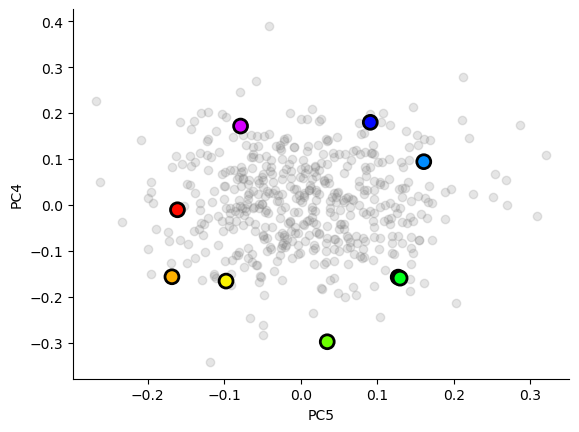

In [114]:
fig = plt.figure()

plt.scatter(z_neuron[:, pc_list[0]], z_neuron[:, pc_list[1]],color="grey",alpha=.2)

neurons_to_plot = np.array([181, 59, 189, 103, 196, 488, 233, 85, 425])
color_list = plt.cm.hsv((z_angle[neurons_to_plot] + np.pi) / (2 * np.pi))
plt.scatter(z_neuron[neurons_to_plot, pc_list[0]], z_neuron[neurons_to_plot, pc_list[1]], color=color_list, s=100, edgecolors="k", lw=2)
plt.xlabel(f"PC{pc_list[0]+1}")
plt.ylabel(f"PC{pc_list[1]+1}")
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

In [22]:
sm.GLM?

Init signature:
sm.GLM(
    endog,
    exog,
    family=None,
    offset=None,
    exposure=None,
    freq_weights=None,
    var_weights=None,
    missing='none',
    **kwargs,
)
Docstring:     
Generalized Linear Models

GLM inherits from statsmodels.base.model.LikelihoodModel

Parameters
----------
endog : array_like
    1d array of endogenous response variable.  This array can be 1d or 2d.
    Binomial family models accept a 2d array with two columns. If
    supplied, each observation is expected to be [success, failure].
exog : array_like
    A nobs x k array where `nobs` is the number of observations and `k`
    is the number of regressors. An intercept is not included by default
    and should be added by the user (models specified using a formula
    include an intercept by default). See `statsmodels.tools.add_constant`.
family : family class instance
    The default is Gaussian.  To specify the binomial distribution
    family = sm.family.Binomial()
    Each family can take a l

In [223]:
mark = "run_start"
window = (-.5,.5)
output = "Q_leaf_A_update"

mark = "t_choice"
window = (-0,1)
output = "Q_leaf_A_update"


_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]
_df = _df[_df["n_post_switch"] > 1]
_df = _df[~np.isnan(_df[output])]
# _df = _df[_df.prev_trial_reward == 0]


results = np.zeros((len(sorted_df), len(_df)))
for i_mark, m in enumerate(_df[mark].values):
    for i, s in enumerate(sorted_df.spike_times.values):
        st = np.searchsorted(s, m + window[0])
        en = np.searchsorted(s, m + window[-1])
        results[i, i_mark] = en - st
results = np.log2(results +1)

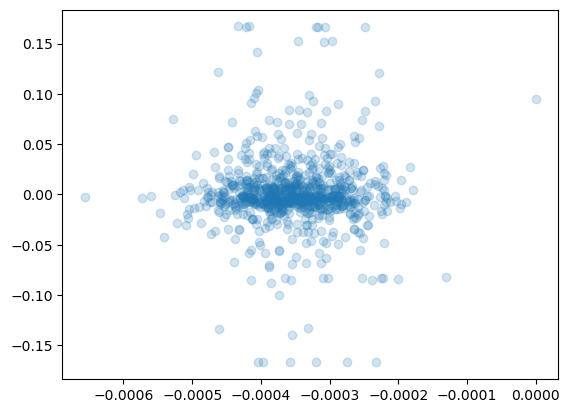

In [224]:
target_pc = 7

z_neuron = np.array([xx for xx in sorted_df.z_neuron.values])
weighted_results = results.copy()+1
weighted_results = weighted_results / np.mean(weighted_results, axis=0, keepdims=True)
weighted_results = np.log2(weighted_results)
weighted_results = (weighted_results * z_neuron[:, target_pc][:, np.newaxis]) /  np.abs(z_neuron[:, target_pc]).sum()
weighted_results = weighted_results.mean(axis=0)

plt.scatter(weighted_results,_df[output].values,alpha = .2)

In [193]:
from scipy.stats import linregress

slopes = []
p_vals = []
for i in range(len(sorted_df)):
    fit = linregress( _df[output].values, results[i,:],)
    plot_x = np.array([_df[output].min(), _df[output].max()])
    plot_y = fit.slope * plot_x + fit.intercept
    # plt.scatter(_df[output].values, results[i,:], alpha=0.5)
    # plt.plot(plot_x, plot_y, color="r", linewidth=2)
    # slopes.append(fit.slope)
    slopes.append(fit.rvalue)
    p_vals.append(fit.pvalue)
slopes = np.array(slopes)
pvals = np.array(p_vals)

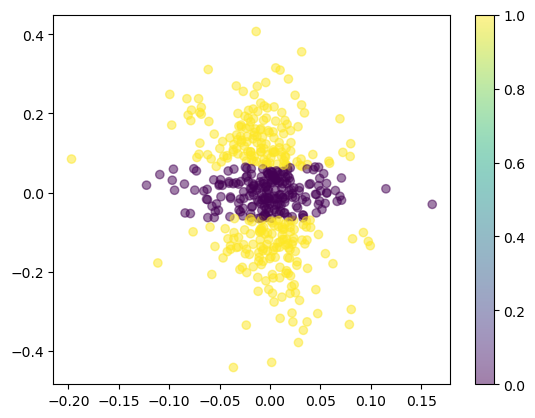

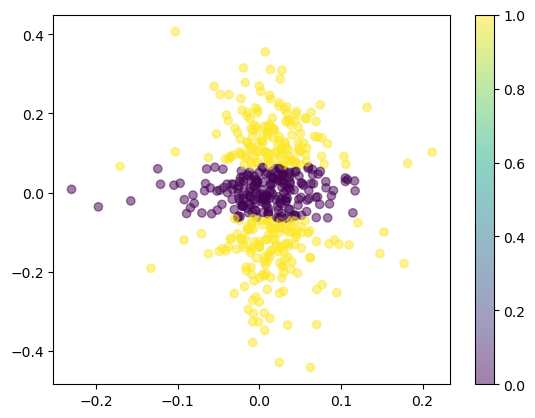

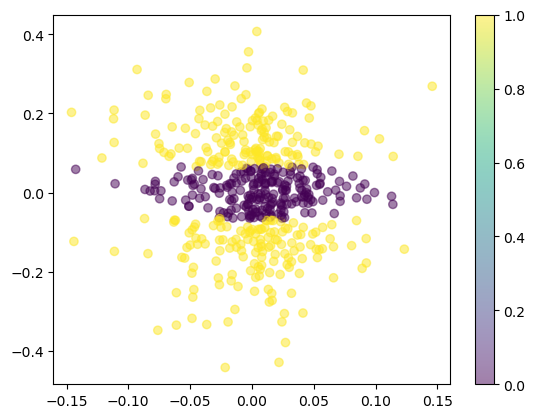

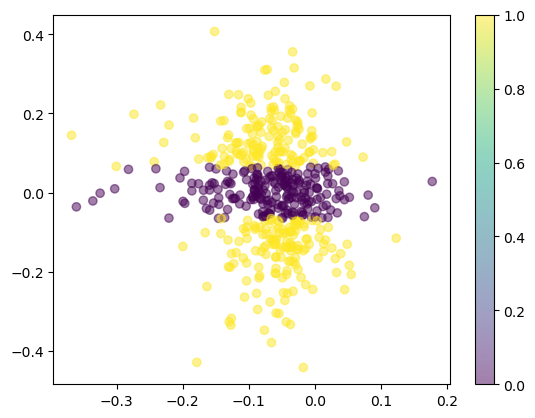

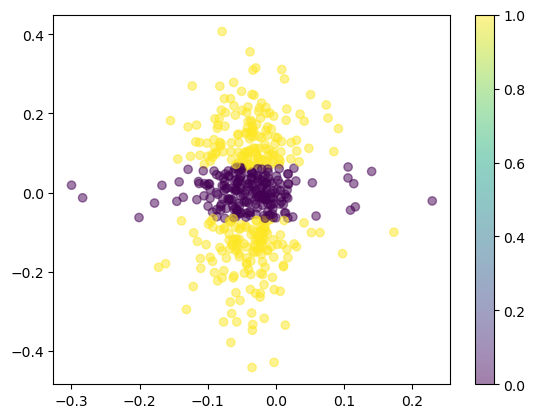

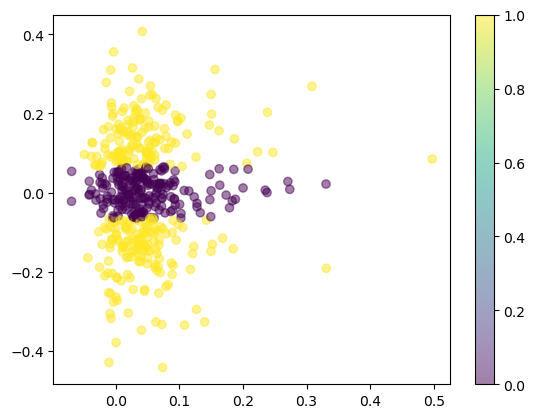

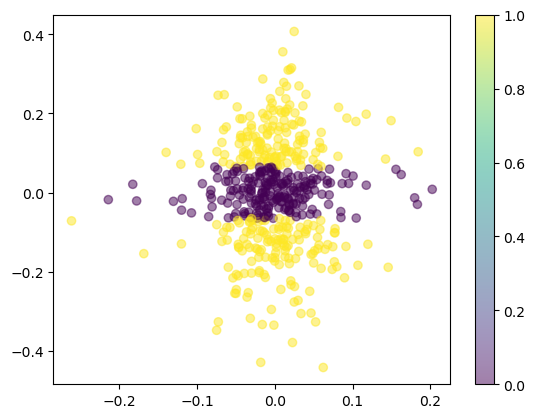

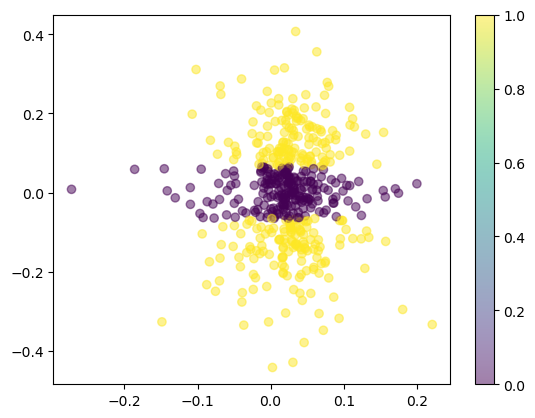

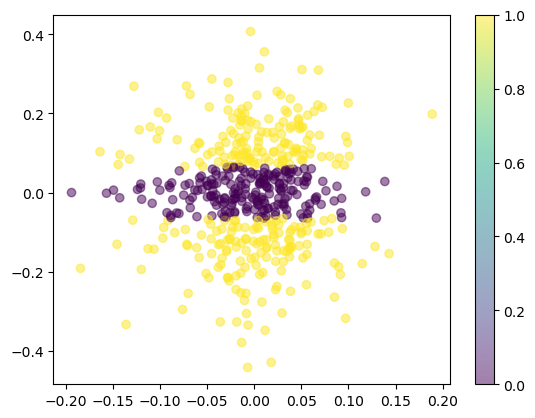

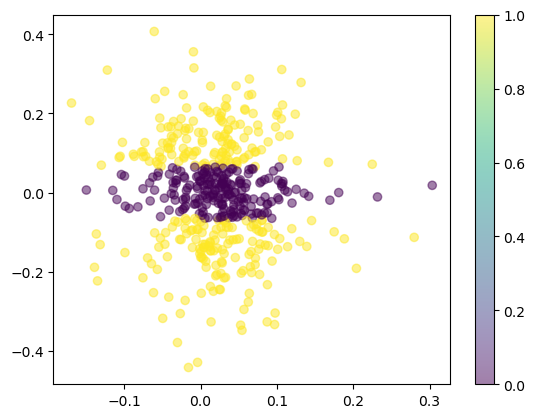

In [195]:
for i in range(10):
    pc_ref = i
    fig = plt.figure()
    z_neuron = np.array([xx for xx in sorted_df.z_neuron.values])[:, pc_ref]
    ind = np.argsort(z_neuron)
    ind = np.where(np.abs(z_neuron) > 0.1)[0]
    # ind = np.where(p_va)

    plt.scatter(z_neuron, slopes, c =pvals<.05, alpha=0.5)
    plt.colorbar()


In [146]:
fit

LinregressResult(slope=np.float64(-9.151125523171013), intercept=np.float64(1.7459424700314363), rvalue=np.float64(-0.09713123395041003), pvalue=np.float64(0.014112006769603657), stderr=np.float64(3.7181649515677546), intercept_stderr=np.float64(0.14559408751281414))

In [123]:
list(_df.columns)

['nwb_file_name',
 'epoch',
 'trial_number_by_epoch',
 'leaf',
 'stem',
 'reward',
 'contingency',
 'date',
 'session',
 'rewscaled',
 'stemchoice',
 'leafchoice',
 'daynum',
 'daysessionnum',
 'stemswitch',
 'n_post_switch',
 'n_pre_switch',
 'cont_combo',
 'contingency_base',
 'cont_base_combo',
 'sub',
 'betadist_α1',
 'betadist_α2',
 'betadist_α3',
 'betadist_α4',
 'betadist_α5',
 'betadist_α6',
 'betadist_β1',
 'betadist_β2',
 'betadist_β3',
 'betadist_β4',
 'betadist_β5',
 'betadist_β6',
 'betadist_var1',
 'betadist_var2',
 'betadist_var3',
 'betadist_var4',
 'betadist_var5',
 'betadist_var6',
 'Q1',
 'Q2',
 'Q3',
 'Q4',
 'Q5',
 'Q6',
 'Qdep1',
 'Qdep2',
 'Qdep3',
 'Qdep4',
 'Qdep5',
 'Qdep6',
 'Qstem1',
 'Qstem2',
 'Qstem3',
 'Qstem1_nobias',
 'Qstem2_nobias',
 'Qstem3_nobias',
 'Qstem1_pre_update_post_bias',
 'Qstem2_pre_update_post_bias',
 'Qstem3_pre_update_post_bias',
 'Qleaf1',
 'Qleaf2',
 'stem_stay_p',
 'stem_turn_alone_p',
 'stem_go_turn_p',
 'stem_1_p',
 'stem_2_p',
 's

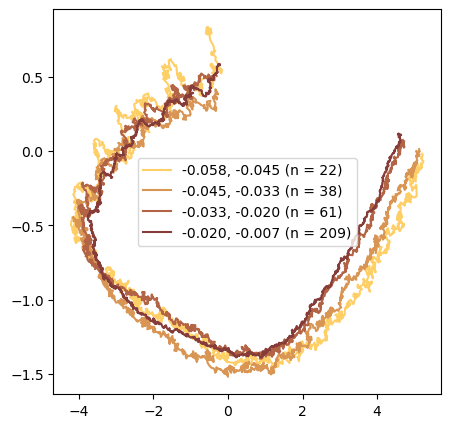

In [ ]:
pcs_2d = [1, 3]
range_val = (-1.2,1.2)

_df = trial_df.copy()
# _df = _df[_df.prev_trial_reward == 0]
_df = _df[_df.n_pre_switch > 0]

mark_list =  "run_start"
condition_type = "range"
condition_feature = "Q_leaf_A_update"
percentiles = np.linspace(5,95,7)
condition_values = np.nanpercentile(_df[condition_feature], percentiles)
condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
condition_values  = condition_values[condition_values <= 0]
condition_groups = []
condition_labels = []
condition_colors = []
if condition_type == "range":
    for i in range(len(condition_values) - 1):
        condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
        condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
        color = np.mean(condition_values[i:i+2])
        val_mids = (condition_values[1:] + condition_values[:-1]) / 2
        color = color / np.max(np.abs(val_mids))
        color += 1
        color = color /2
        condition_colors.append(plt.cm.managua(color))

fig = plt.figure(figsize=(5, 5))
ax = fig.gca()
for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        mark_times = group[mark].values
        if len(mark_times) == 0:
            continue
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        # results = results[:, ::2]

        mid = np.nanmean(results, axis=0)
        # lo = np.nanpercentile(results, 25, axis=0)
        # hi = np.nanpercentile(results, 75, axis=0)
        t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset

        ax.plot(mid[:, pcs_2d[0]], mid[:, pcs_2d[1]], label=label, color=color)
        # if label == condition_labels[0]:
        #     ax_2d.text(mid[0, pcs_2d[0]]* 1.1, mid[0, pcs_2d[1]] * 1.1, mark, ha="left", va="bottom")

ax.legend()


In [28]:
_df

[2       False
 3        True
 5        True
 9        True
 10       True
         ...  
 1411    False
 1412    False
 1413    False
 1414    False
 1415    False
 Name: n_pre_switch, Length: 892, dtype: bool]

# Aligned Responses PER EPOCH

### select data

In [7]:
_df = trial_df.copy()
_df = _df[_df["n_pre_switch"] > 0]

##########################
### Regular categories
##########################
condition_type = "category"
condition_feature = "prev_trial_reward"
condition_values = _df[condition_feature].unique()
condition_values = condition_values[~np.isnan(condition_values)]
condition_groups = []
condition_labels = []
condition_colors = []

if condition_type == "category":
    for value in condition_values:
        condition_groups.append(_df[_df[condition_feature] == value])
        condition_labels.append(f"{condition_feature} = {value}")
        condition_colors.append(f"C{len(condition_groups) - 1}")

##########################
### N pre switch categories
##########################
condition_type = "category"
condition_feature = "n_pre_switch"
condition_values = _df[condition_feature].unique()
condition_values = [1,2,3,4,5,6,0]

condition_groups = []
condition_labels = []
condition_colors = []
if condition_type == "category":
    for i, value in enumerate(condition_values):
        condition_groups.append(_df[_df[condition_feature] == value])
        condition_labels.append(f"{condition_feature} = {value}")
        # condition_colors.append(plt.cm.plasma(value/len(condition_values)) if value else "r")
        condition_colors.append(plt.cm.plasma(i/len(condition_values)) if value else "r")


##########################
### Range categories
##########################
condition_type = "range"
condition_feature = "Q_leaf_A_update"
percentiles = np.linspace(5,95,7)
condition_values = np.nanpercentile(_df[condition_feature], percentiles)
condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
condition_groups = []
condition_labels = []
condition_colors = []
if condition_type == "range":
    for i in range(len(condition_values) - 1):
        condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
        condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
        color = np.mean(condition_values[i:i+2])
        val_mids = (condition_values[1:] + condition_values[:-1]) / 2
        color = color / np.max(np.abs(val_mids))
        color += 1
        color = color /2
        condition_colors.append(plt.cm.managua(color))


# condition_type = "range"
# condition_feature = "Q_leaf_B"
# df = _df[_df.reward==1]
# percentiles = np.linspace(5,95,7)
# condition_values = np.nanpercentile(_df[condition_feature], percentiles)
# condition_values = np.linspace(condition_values[0], condition_values[-1], 11)
# condition_groups = []
# condition_labels = []
# condition_colors = []
# if condition_type == "range":
#     for i in range(len(condition_values) - 1):
#         condition_groups.append(_df[(_df[condition_feature] >= condition_values[i]) & (_df[condition_feature] < condition_values[i+1])])
#         condition_labels.append(f"{condition_values[i]:.3f}, {condition_values[i+1]:.3f} (n = {len(condition_groups[-1])})")
#         color = np.mean(condition_values[i:i+2])
#         val_mids = (condition_values[1:] + condition_values[:-1]) / 2
#         color = color - np.min(val_mids)
#         color = color / np.max(val_mids - np.min(val_mids))
#         color += 1
#         color = color /2
#         condition_colors.append(plt.cm.magma(color))

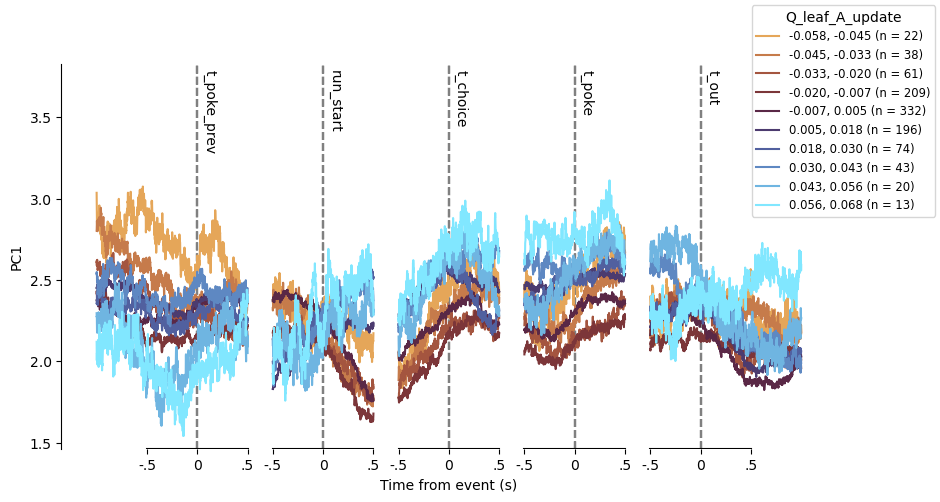

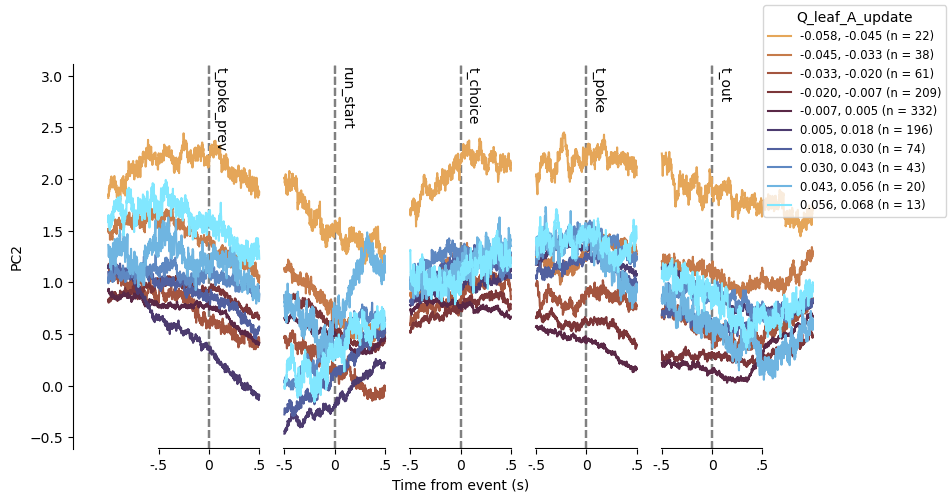

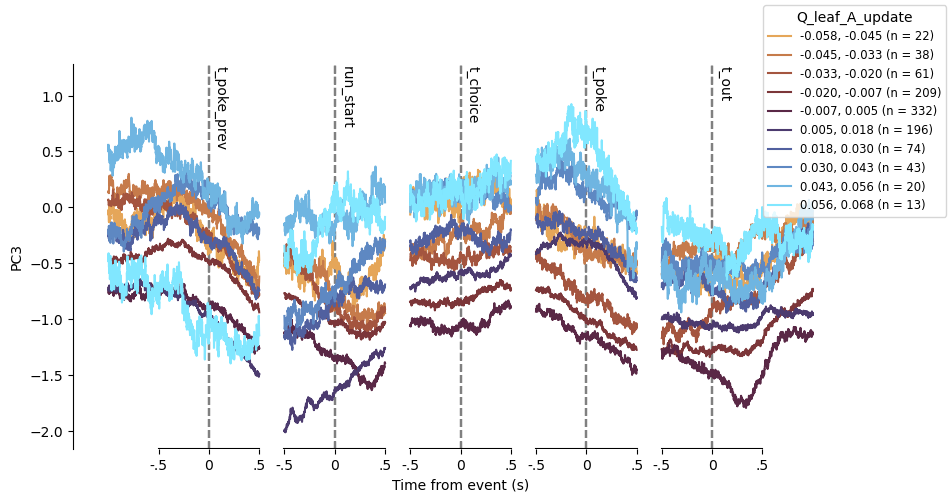

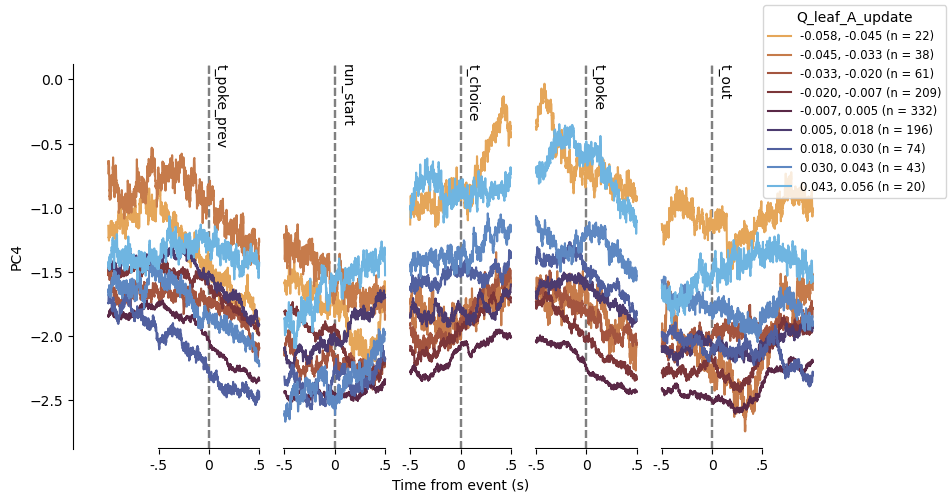

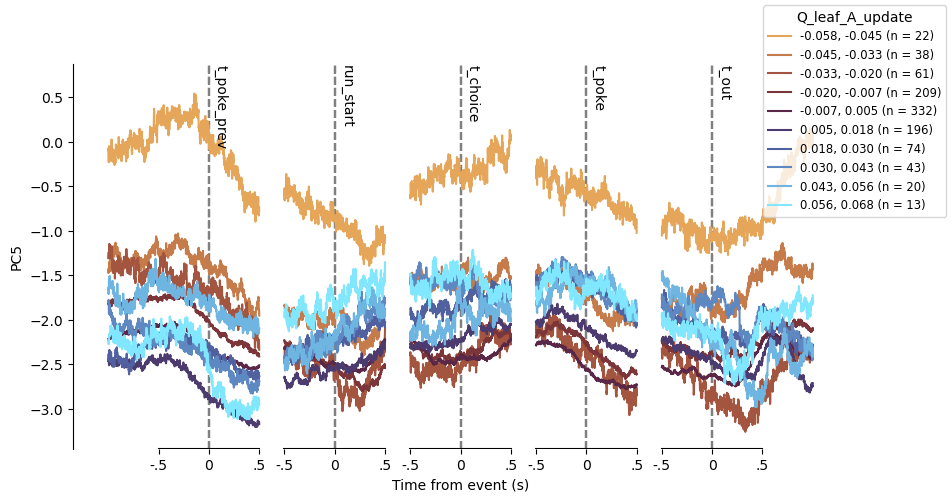

In [ ]:
mark_list = ["t_poke_prev", "run_start", "t_choice", "t_poke", "t_out"]
offset_list = [-1.25, 0, 1.25, 2.5, 3.75]
range_list = [(-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 1)]

pc_to_plot = 2

epochs = trial_df["epoch"].unique()
figure_list = [plt.figure(figsize=(10, 5)) for _ in epochs]

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for group, label, color in zip(condition_groups, condition_labels, condition_colors):
        for epoch, fig in zip(epochs, figure_list):
            if epoch not in group["epoch"].values:
                continue
            group_epoch = group[group["epoch"] == epoch]
            mark_times = group_epoch[mark].values
            if len(mark_times) == 0:
                continue
            results = analysis.alligned_response(mark_times, range_val, pca=True)
            # results = results[:, ::2]

            mid = np.nanmean(results, axis=0)
            # lo = np.nanpercentile(results, 25, axis=0)
            # hi = np.nanpercentile(results, 75, axis=0)
            t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset

            ax = fig.gca()
            ax.plot(t_plot,mid[:, pc_to_plot], label=label if mark == mark_list[0] else None, color=color)
            # ax.fill_between(t_plot, lo[:,i], hi[:,i], facecolor=color, alpha=0.2)
            ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)


for pc,fig in enumerate(figure_list):
    ax = fig.gca()
    ylim = ax.get_ylim()
    ylim_top = ylim[1] * 1.2
    ax.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

    ticks = []
    labels = []
    for mark, offset in zip(mark_list, offset_list):
        xx = np.array([-0.5, 0, 0.5])
        ticks.append(xx + offset)
        labels.append(["-.5", "0", ".5"])
        ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)
    ax.set_xlabel("Time from event (s)")

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    ax.set_ylabel(f"PC{pc+1}")

sub_dir = fig_dir/ f"per_epoch_results/{condition_feature}"
sub_dir.mkdir(parents=True, exist_ok=True)
for i,fig in enumerate(figure_list):
    # fig.savefig(sub_dir / f"pc_{pc+1}.png", dpi=300, bbox_inches="tight")
    fig.savefig(sub_dir / f"pc_{pc_to_plot}_epoch_{epochs[i]}.svg")